In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from scipy.stats import mode

from xgboost import XGBRegressor

from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from xgboost import XGBClassifier

from sklearn.inspection import permutation_importance

# Loading Dataset

In [2]:
!git clone https://github.com/djmans630/DSC148_Project.git

df = pd.read_csv('DSC148_Project/nhtsa_vehicle_safety_recall_intelligence_ultimate.csv')
print(len(df))

fatal: destination path 'DSC148_Project' already exists and is not an empty directory.
47707


In [3]:
df.head(5)

,record_id,nhtsa_record_id,recall_campaign_id,manufacturer_campaign_id,vehicle_make,vehicle_model,vehicle_year,vehicle_year_num,vehicle_era,manufacturer_name,...,source_url,scrape_date,dataset_version,record_creation_date,RCL_CMPT_ID,MFR_COMP_NAME,MFR_COMP_DESC,MFR_COMP_PTNO,creation_date_parsed,defect_severity_score
0,835d8908b3a39d,105867,14V400000,14350,OLDSMOBILE,INTRIGUE,1998.0,1998.0,1990s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,000056617000202679000000212,NaN,NaN,NaN,2014-07-07,0.3979
1,1e393b1efc0ea4,105872,14V400000,14350,CHEVROLET,MALIBU CLASSIC,2005.0,2005.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,000056617000204360000000212,NaN,NaN,NaN,2014-07-07,0.3979
2,1ea55f8d43bf01,105885,14V400000,14350,OLDSMOBILE,ALERO,2001.0,2001.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,000056617000202733000000212,NaN,NaN,NaN,2014-07-07,0.3979
3,3588d2734c086b,105883,14V400000,14350,PONTIAC,GRAND AM,2000.0,2000.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,000056617000202623000000212,NaN,NaN,NaN,2014-07-07,0.3979
4,ab8db036507579,105882,14V400000,14350,PONTIAC,GRAND AM,2002.0,2002.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,000056617000202625000000212,NaN,NaN,NaN,2014-07-07,0.3979


In [4]:
# dimensions
df.shape

(47707, 53)

In [5]:
# columns
for i in df.columns:
  print(i)

record_id
nhtsa_record_id
recall_campaign_id
manufacturer_campaign_id
vehicle_make
vehicle_model
vehicle_year
vehicle_year_num
vehicle_era
manufacturer_name
manufacturer_text
make_origin
recall_type_code
recall_type_label
component_name
component_category
recall_initiation_date
recall_date_parsed
report_received_date
owner_notification_date
notification_date_parsed
manufacture_date_begin
manufacture_date_end
recall_year
recall_month
recall_quarter
recall_age_days
days_to_owner_notification
potential_units_affected
units_affected_num
recall_scale
defect_summary
consequence_summary
corrective_action
notes
defect_severity
fire_risk_flag
manufacturer_recall_count
is_repeat_manufacturer
recall_risk_score
risk_tier
influenced_by
data_source
source_url
scrape_date
dataset_version
record_creation_date
RCL_CMPT_ID
MFR_COMP_NAME
MFR_COMP_DESC
MFR_COMP_PTNO
creation_date_parsed
defect_severity_score


In [6]:
# current goal: predict defect severity score

# EDA

In [7]:
interesting_cols = ['component_category','vehicle_make','recall_type_label', 'units_affected_num', 'fire_risk_flag']

#Potential Predictors
print(df['defect_severity'].value_counts())

#Maybe look at if manufacturer is a predictor
df[interesting_cols]

defect_severity
MEDIUM      12908
LOW         12073
HIGH        12033
CRITICAL    10693
Name: count, dtype: int64


,component_category,vehicle_make,recall_type_label,units_affected_num,fire_risk_flag
0,Air Bag,OLDSMOBILE,Vehicle,5877718,0
1,Air Bag,CHEVROLET,Vehicle,5877718,0
2,Air Bag,OLDSMOBILE,Vehicle,5877718,0
3,Air Bag,PONTIAC,Vehicle,5877718,0
4,Air Bag,PONTIAC,Vehicle,5877718,0
...,...,...,...,...,...
47702,Steering,CHEVROLET,Vehicle,2399,0
47703,Steering,CHEVROLET,Vehicle,2399,0
47704,Steering,ISUZU,Vehicle,2399,0
47705,Steering,ISUZU,Vehicle,2399,0


In [8]:
df['defect_severity_score'].sort_values(ascending=False)

,defect_severity_score
26345,0.5233
26327,0.5233
26315,0.5233
26287,0.5233
26286,0.5233
...,...
18965,0.0872
18967,0.0872
10204,0.0538
5704,0.0538


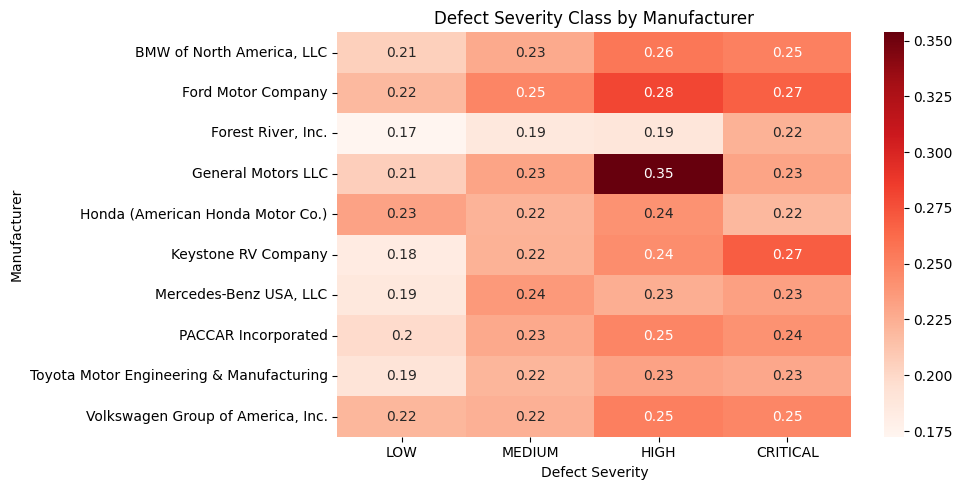

In [9]:
top = (df['manufacturer_name'].value_counts().head(10).index)
filtered = df[df['manufacturer_name'].isin(top)]
data = filtered.pivot_table(values='defect_severity_score', index='manufacturer_name', columns='defect_severity',aggfunc='mean')
severity_order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
data = data[severity_order]
plt.figure(figsize=(10, 5))

sns.heatmap(data, annot=True, cmap="Reds")

plt.title("Defect Severity Class by Manufacturer")
plt.xlabel("Defect Severity")
plt.ylabel("Manufacturer")
plt.tight_layout()
plt.show()

In [10]:
df.groupby('make_origin')['defect_severity_score'].mean()

,defect_severity_score
make_origin,
EV-First Brand,0.264449
European,0.239403
German,0.222416
Japanese,0.229951
Korean,0.231021
Other,0.240403
US Domestic,0.249014


In [11]:
df.groupby('vehicle_model')['defect_severity_score'].mean()

,defect_severity_score
vehicle_model,
!ESCAPE 21,0.371900
!MX-5,0.217700
1 SERIES,0.211882
1 SERIES M,0.186650
1.5L ECOBOOST RFF CYLINDER HEAD,0.234300
...,...
redundant RX PLUG-IN HYBRID,0.193100
redundant SEISMIC,0.187060
redundant SIENNA,0.227200


In [12]:
df.groupby('component_category')['defect_severity_score'].mean()

,defect_severity_score
component_category,
Air Bag,0.241633
Brakes,0.261222
Child Seat,0.246500
Electrical,0.231402
Engine / Powertrain,0.245486
Fire Risk,0.284637
Fuel System,0.233164
Other,0.213442
Seat Belts,0.254284


In [13]:
df.groupby('vehicle_era')['defect_severity_score'].mean()

,defect_severity_score
vehicle_era,
1980s,0.221963
1990s,0.245861
2000s,0.241504
2010s,0.238209
2020s,0.240705


In [14]:
df.groupby('is_repeat_manufacturer')['defect_severity_score'].mean()

,defect_severity_score
is_repeat_manufacturer,
0,0.253316
1,0.239698


In [15]:
df.groupby('influenced_by')['defect_severity_score'].mean()

,defect_severity_score
influenced_by,
MFR,0.241849
ODI,0.230191
OVSC,0.250077


In [16]:
df.head()

,record_id,nhtsa_record_id,recall_campaign_id,manufacturer_campaign_id,vehicle_make,vehicle_model,vehicle_year,vehicle_year_num,vehicle_era,manufacturer_name,...,source_url,scrape_date,dataset_version,record_creation_date,RCL_CMPT_ID,MFR_COMP_NAME,MFR_COMP_DESC,MFR_COMP_PTNO,creation_date_parsed,defect_severity_score
0,835d8908b3a39d,105867,14V400000,14350,OLDSMOBILE,INTRIGUE,1998.0,1998.0,1990s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,000056617000202679000000212,NaN,NaN,NaN,2014-07-07,0.3979
1,1e393b1efc0ea4,105872,14V400000,14350,CHEVROLET,MALIBU CLASSIC,2005.0,2005.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,000056617000204360000000212,NaN,NaN,NaN,2014-07-07,0.3979
2,1ea55f8d43bf01,105885,14V400000,14350,OLDSMOBILE,ALERO,2001.0,2001.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,000056617000202733000000212,NaN,NaN,NaN,2014-07-07,0.3979
3,3588d2734c086b,105883,14V400000,14350,PONTIAC,GRAND AM,2000.0,2000.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,000056617000202623000000212,NaN,NaN,NaN,2014-07-07,0.3979
4,ab8db036507579,105882,14V400000,14350,PONTIAC,GRAND AM,2002.0,2002.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707,000056617000202625000000212,NaN,NaN,NaN,2014-07-07,0.3979


In [17]:
df.corr(numeric_only=True)

,nhtsa_record_id,vehicle_year,vehicle_year_num,recall_initiation_date,owner_notification_date,manufacture_date_begin,manufacture_date_end,recall_year,recall_month,recall_quarter,recall_age_days,days_to_owner_notification,potential_units_affected,units_affected_num,fire_risk_flag,manufacturer_recall_count,is_repeat_manufacturer,recall_risk_score,record_creation_date,defect_severity_score
nhtsa_record_id,1.000000,0.719408,0.719408,0.929470,2.821069e-01,0.255001,0.405626,0.929259,-0.031802,-0.043993,-0.929186,0.001388,-5.903232e-02,-5.903232e-02,0.013671,0.206499,0.015365,0.026174,0.929579,0.043050
vehicle_year,0.719408,1.000000,1.000000,0.737920,2.160101e-01,0.352829,0.485995,0.737627,-0.009813,-0.023617,-0.738561,-0.067117,-1.448785e-01,-1.448785e-01,0.023943,0.106829,-0.006365,0.020159,0.738762,-0.000050
vehicle_year_num,0.719408,1.000000,1.000000,0.737920,2.160101e-01,0.352829,0.485995,0.737627,-0.009813,-0.023617,-0.738561,-0.067117,-1.448785e-01,-1.448785e-01,0.023943,0.106829,-0.006365,0.020159,0.738762,-0.000050
recall_initiation_date,0.929470,0.737920,0.737920,1.000000,3.058870e-01,0.244028,0.418397,0.999968,-0.058342,-0.068319,-0.998234,0.027784,-2.888576e-02,-2.888576e-02,0.017690,0.218205,0.020063,0.049207,0.999665,0.058357
owner_notification_date,0.282107,0.216010,0.216010,0.305887,1.000000e+00,0.041834,0.075258,0.305736,0.004033,0.004496,-0.306353,0.086947,-1.650554e-07,-1.650554e-07,0.006587,0.070948,0.005252,0.030498,0.305975,0.028589
manufacture_date_begin,0.255001,0.352829,0.352829,0.244028,4.183381e-02,1.000000,0.180900,0.243727,0.031869,0.032330,-0.245552,-0.050726,-3.406029e-02,-3.406029e-02,0.007403,0.029975,-0.017871,-0.004708,0.244131,-0.027321
manufacture_date_end,0.405626,0.485995,0.485995,0.418397,7.525770e-02,0.180900,1.000000,0.417773,0.065492,0.061559,-0.421893,-0.048291,-7.549645e-02,-7.549645e-02,0.018553,0.021732,-0.006639,0.050511,0.418454,0.006624
recall_year,0.929259,0.737627,0.737627,0.999968,3.057364e-01,0.243727,0.417773,1.000000,-0.066336,-0.076110,-0.997727,0.027767,-2.847961e-02,-2.847961e-02,0.017622,0.218576,0.019976,0.048694,0.999627,0.057981
recall_month,-0.031802,-0.009813,-0.009813,-0.058342,4.033479e-03,0.031869,0.065492,-0.066336,1.000000,0.974879,-0.000858,-0.000548,-4.885182e-02,-4.885182e-02,0.007438,-0.059868,0.009322,0.061100,-0.057646,0.043230
recall_quarter,-0.043993,-0.023617,-0.023617,-0.068319,4.496174e-03,0.032330,0.061559,-0.076110,0.974879,1.000000,0.010544,-0.007832,-4.769432e-02,-4.769432e-02,0.011087,-0.072813,0.010236,0.060234,-0.067571,0.032385


In [18]:
df.shape

(47707, 53)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47707 entries, 0 to 47706
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   record_id                   47707 non-null  object 
 1   nhtsa_record_id             47707 non-null  int64  
 2   recall_campaign_id          47707 non-null  object 
 3   manufacturer_campaign_id    33642 non-null  object 
 4   vehicle_make                47707 non-null  object 
 5   vehicle_model               47707 non-null  object 
 6   vehicle_year                46705 non-null  float64
 7   vehicle_year_num            46705 non-null  float64
 8   vehicle_era                 46705 non-null  object 
 9   manufacturer_name           47707 non-null  object 
 10  manufacturer_text           47707 non-null  object 
 11  make_origin                 47707 non-null  object 
 12  recall_type_code            47707 non-null  object 
 13  recall_type_label           477

In [20]:
df.describe()

,nhtsa_record_id,vehicle_year,vehicle_year_num,recall_initiation_date,owner_notification_date,manufacture_date_begin,manufacture_date_end,recall_year,recall_month,recall_quarter,recall_age_days,days_to_owner_notification,potential_units_affected,units_affected_num,fire_risk_flag,manufacturer_recall_count,is_repeat_manufacturer,recall_risk_score,record_creation_date,defect_severity_score
count,47707.000000,46705.000000,46705.000000,4.770700e+04,4.649500e+04,2.347300e+04,2.336500e+04,47707.000000,47707.000000,47707.000000,47707.000000,46483.000000,4.770700e+04,4.770700e+04,47707.000000,47707.000000,47707.000000,47707.000000,4.770700e+04,47707.000000
mean,167285.682143,2014.684316,2014.684316,2.018520e+07,2.018392e+07,2.010196e+07,2.014509e+07,2018.452324,6.562685,2.521118,2683.213910,75.455823,2.583387e+05,2.583387e+05,0.004318,4148.963842,0.994424,34.135389,2.018519e+07,0.239774
std,70721.828215,6.411211,6.411211,4.511637e+04,1.524392e+05,1.633487e+05,9.220569e+04,4.513901,3.613877,1.172047,1645.061007,99.396269,6.763782e+05,6.763782e+05,0.065570,7823.761485,0.074463,14.030891,4.513059e+04,0.054547
min,81715.000000,1988.000000,1988.000000,2.010010e+07,1.111111e+07,2.090211e+06,1.900010e+07,2010.000000,1.000000,1.000000,5.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000,0.000000,4.000000,2.010010e+07,0.053800
25%,112204.500000,2010.000000,2010.000000,2.015060e+07,2.015080e+07,2.006050e+07,2.011060e+07,2015.000000,3.000000,1.000000,1355.000000,29.000000,1.159000e+03,1.159000e+03,0.000000,484.000000,1.000000,21.000000,2.015060e+07,0.202000
50%,140588.000000,2015.000000,2015.000000,2.019023e+07,2.019032e+07,2.010070e+07,2.015013e+07,2019.000000,6.000000,2.000000,2610.000000,50.000000,1.545400e+04,1.545400e+04,0.000000,1614.000000,1.000000,32.000000,2.019023e+07,0.234500
75%,217614.500000,2020.000000,2020.000000,2.022080e+07,2.022082e+07,2.014092e+07,2.017120e+07,2022.000000,10.000000,4.000000,3975.000000,69.000000,1.733010e+05,1.733010e+05,0.000000,4177.000000,1.000000,43.000000,2.022080e+07,0.272200
max,321004.000000,2027.000000,2027.000000,2.026042e+07,2.026042e+07,3.019051e+07,3.016063e+07,2026.000000,12.000000,4.000000,5951.000000,2675.000000,1.760000e+07,1.760000e+07,1.000000,44051.000000,1.000000,69.000000,2.026042e+07,0.523300


In [21]:
df.columns

Index(['record_id', 'nhtsa_record_id', 'recall_campaign_id',
       'manufacturer_campaign_id', 'vehicle_make', 'vehicle_model',
       'vehicle_year', 'vehicle_year_num', 'vehicle_era', 'manufacturer_name',
       'manufacturer_text', 'make_origin', 'recall_type_code',
       'recall_type_label', 'component_name', 'component_category',
       'recall_initiation_date', 'recall_date_parsed', 'report_received_date',
       'owner_notification_date', 'notification_date_parsed',
       'manufacture_date_begin', 'manufacture_date_end', 'recall_year',
       'recall_month', 'recall_quarter', 'recall_age_days',
       'days_to_owner_notification', 'potential_units_affected',
       'units_affected_num', 'recall_scale', 'defect_summary',
       'consequence_summary', 'corrective_action', 'notes', 'defect_severity',
       'fire_risk_flag', 'manufacturer_recall_count', 'is_repeat_manufacturer',
       'recall_risk_score', 'risk_tier', 'influenced_by', 'data_source',
       'source_url', 'scrape

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47707 entries, 0 to 47706
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   record_id                   47707 non-null  object 
 1   nhtsa_record_id             47707 non-null  int64  
 2   recall_campaign_id          47707 non-null  object 
 3   manufacturer_campaign_id    33642 non-null  object 
 4   vehicle_make                47707 non-null  object 
 5   vehicle_model               47707 non-null  object 
 6   vehicle_year                46705 non-null  float64
 7   vehicle_year_num            46705 non-null  float64
 8   vehicle_era                 46705 non-null  object 
 9   manufacturer_name           47707 non-null  object 
 10  manufacturer_text           47707 non-null  object 
 11  make_origin                 47707 non-null  object 
 12  recall_type_code            47707 non-null  object 
 13  recall_type_label           477

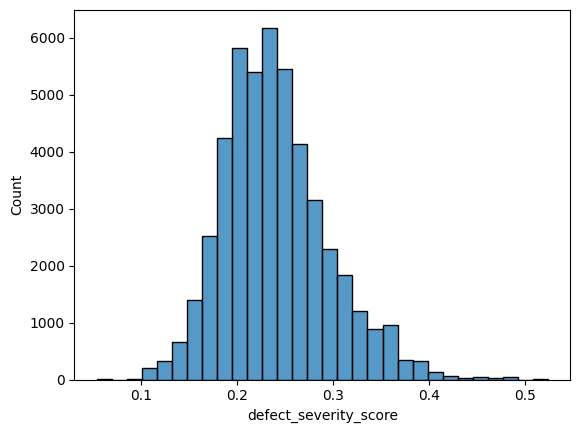

In [23]:
sns.histplot(df['defect_severity_score'], bins=30)
plt.show()

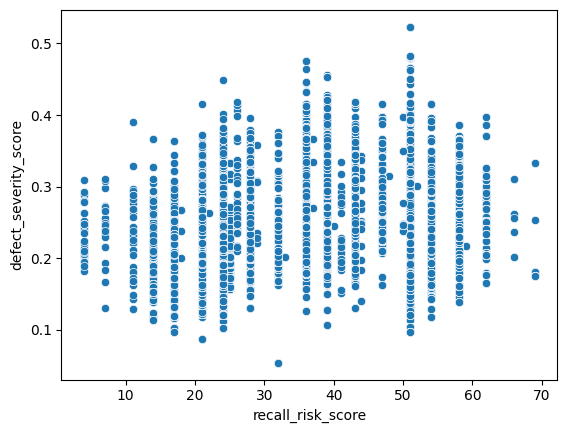

In [24]:
sns.scatterplot(
    data=df,
    x='recall_risk_score',
    y='defect_severity_score'
)

plt.show()

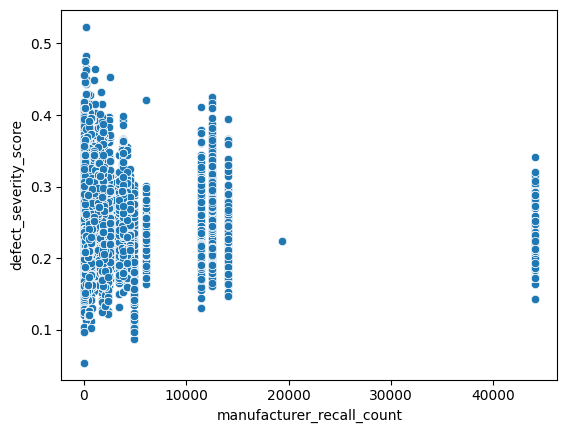

In [25]:
sns.scatterplot(
    data=df,
    x='manufacturer_recall_count',
    y='defect_severity_score'
)

plt.show()

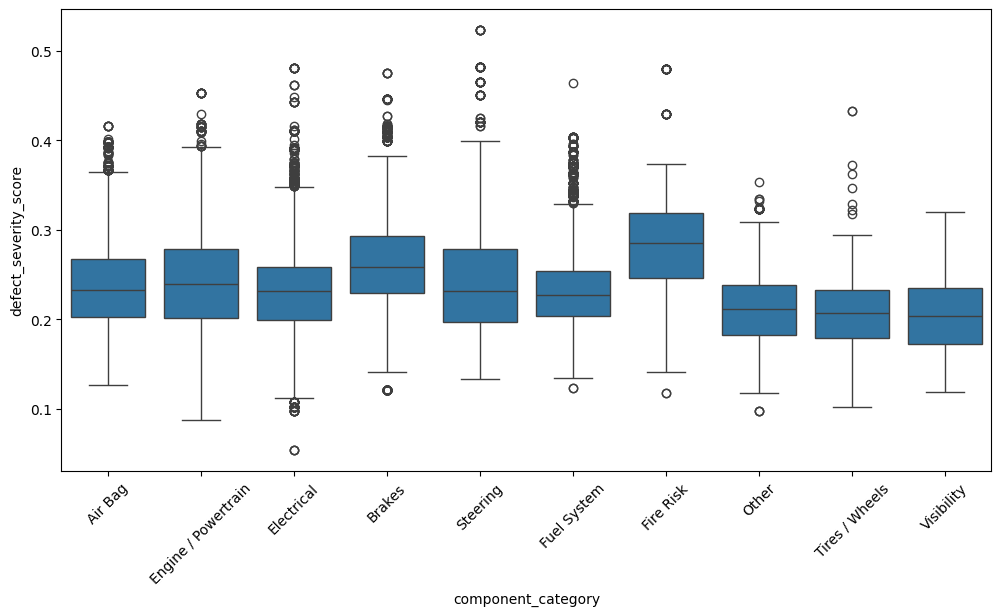

In [26]:
top_components = df['component_category'].value_counts().head(10).index

filtered = df[df['component_category'].isin(top_components)]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=filtered,
    x='component_category',
    y='defect_severity_score'
)

plt.xticks(rotation=45)
plt.show()

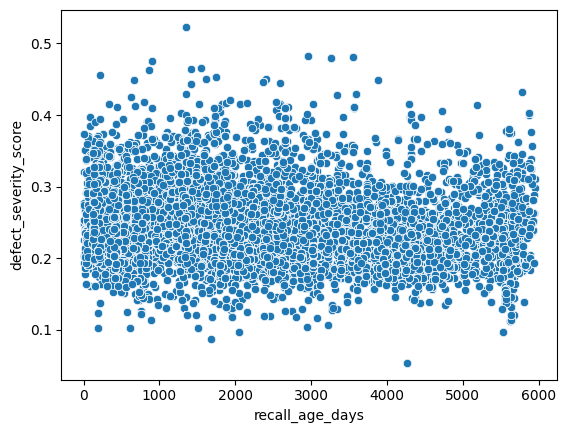

In [27]:
sns.scatterplot(
    data=df,
    x='recall_age_days',
    y='defect_severity_score'
)
plt.show()

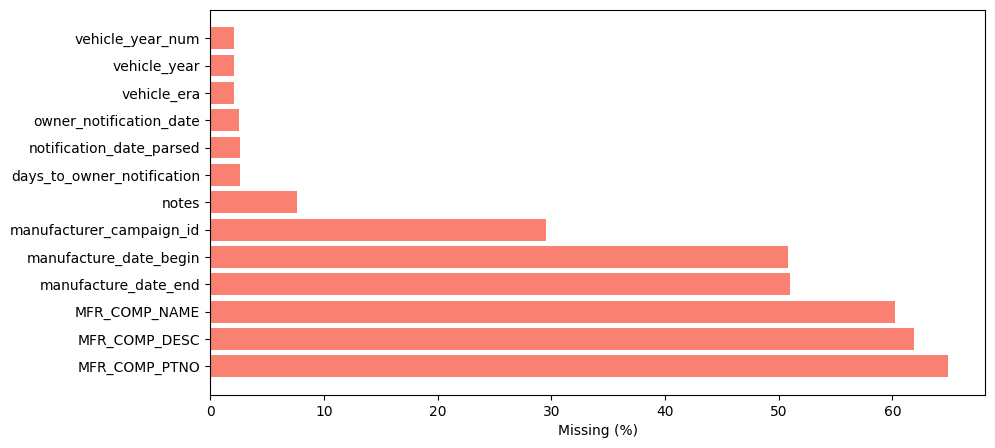

In [28]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing.index, missing_pct, color='salmon')
ax.set_xlabel('Missing (%)')
plt.show()

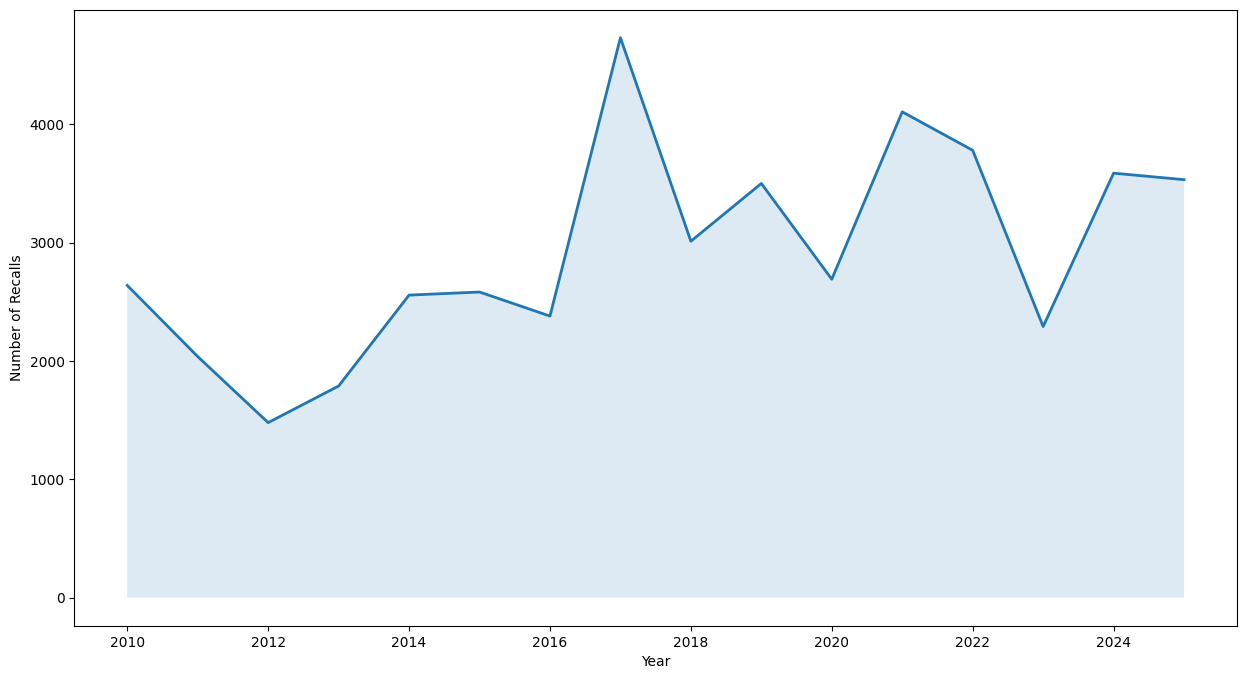

In [29]:
yearly = df[df['recall_year'] <= 2025].groupby('recall_year').size().reset_index(name='count')

plt.figure(figsize=(15, 8))
plt.plot(yearly['recall_year'], yearly['count'], linewidth=2)
plt.fill_between(yearly['recall_year'], yearly['count'], alpha=0.15)
plt.xlabel('Year')
plt.ylabel('Number of Recalls')
plt.show()

In [30]:
df['make_origin'].unique()

array(['Other', 'US Domestic', 'Japanese', 'Korean', 'German', 'European',
       'EV-First Brand'], dtype=object)

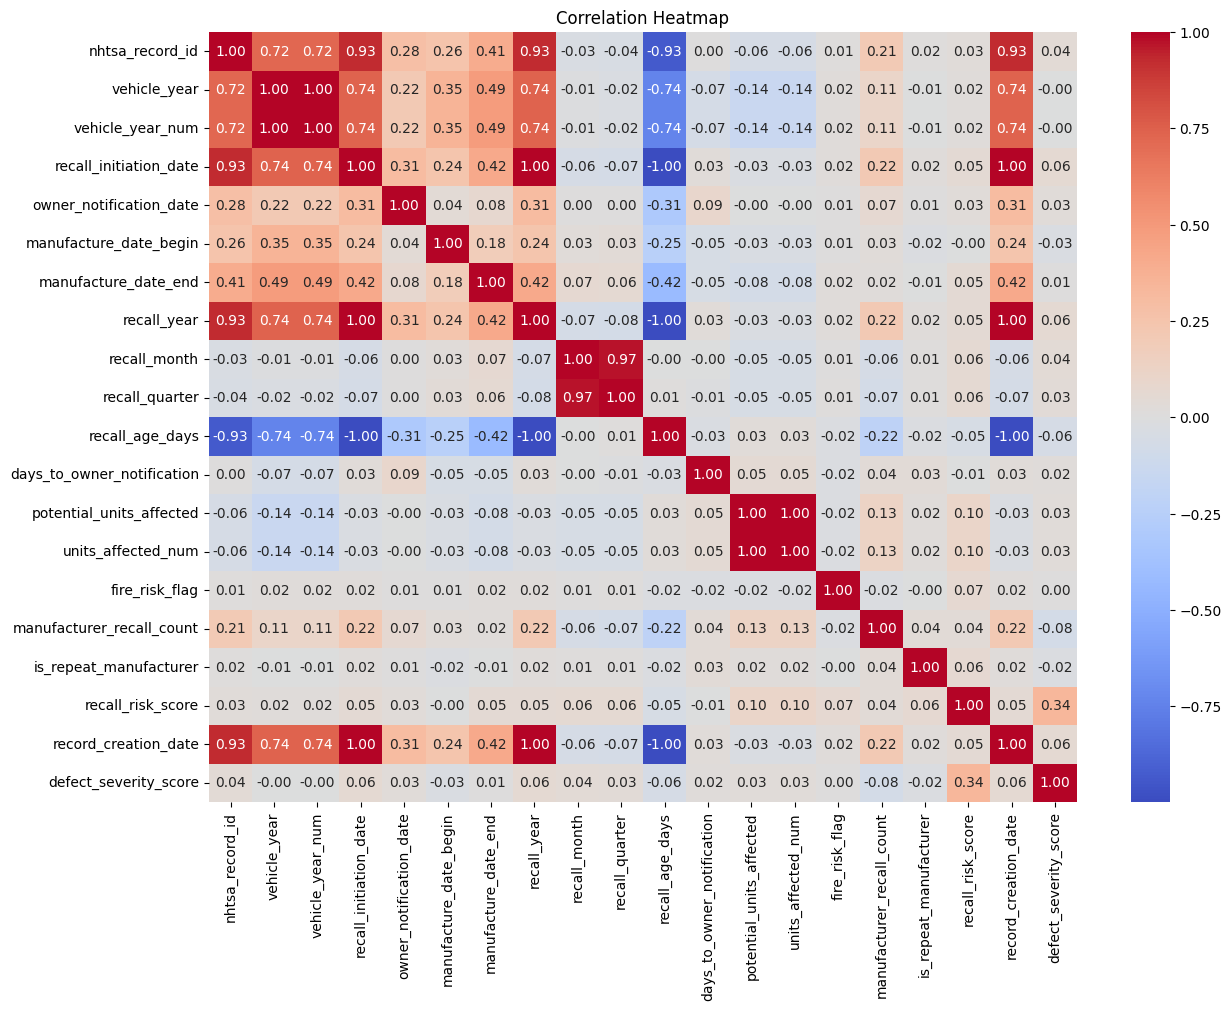

In [31]:
numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

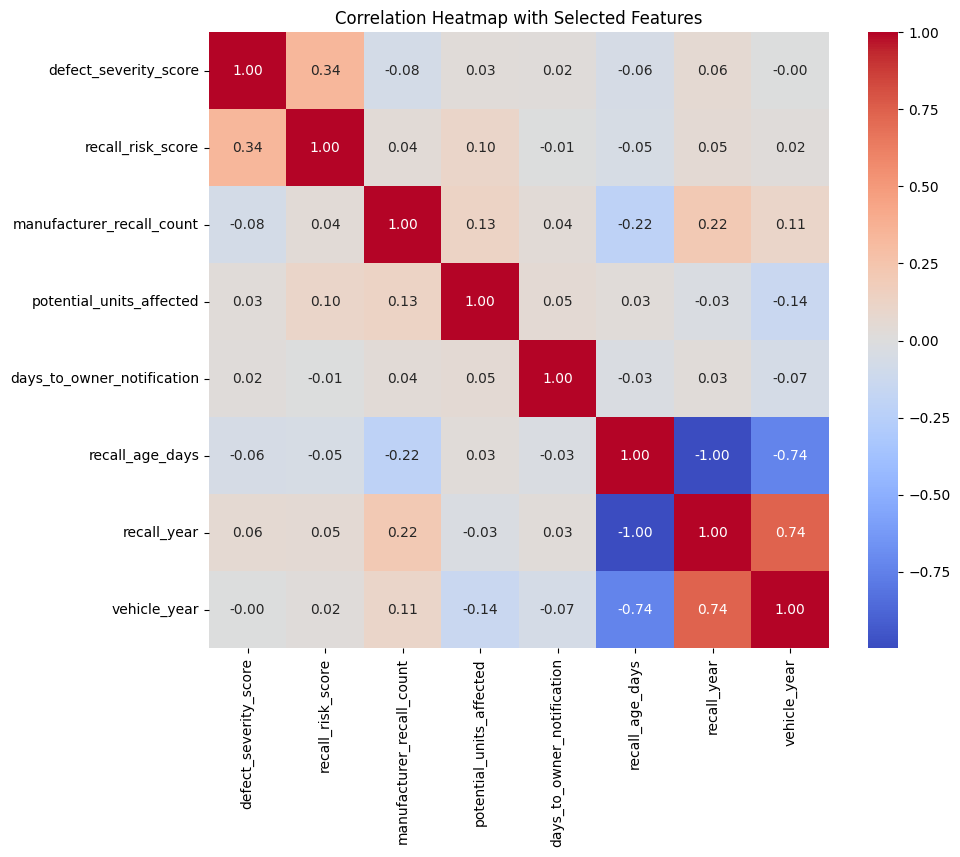

In [32]:
selected_cols = [
    'defect_severity_score', 'recall_risk_score',
    'manufacturer_recall_count', 'potential_units_affected',
    'days_to_owner_notification', 'recall_age_days',
    'recall_year', 'vehicle_year'
]

corr_matrix = df[selected_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap with Selected Features')
plt.show()

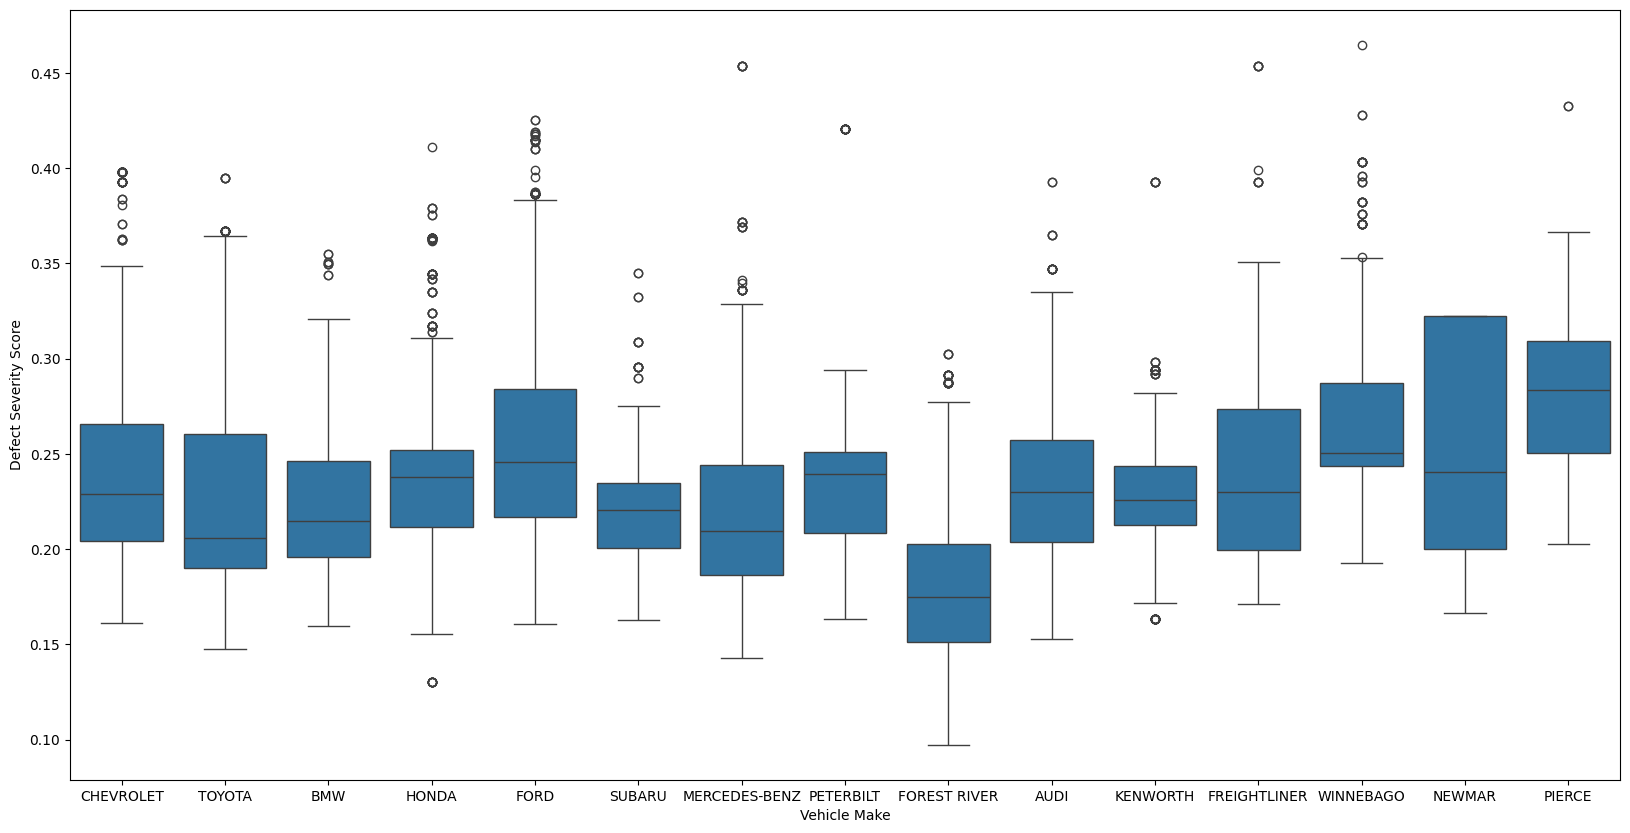

In [33]:
top_makes = df['vehicle_make'].value_counts().head(15).index
filtered_makes = df[df['vehicle_make'].isin(top_makes)]

plt.figure(figsize=(20,10))

sns.boxplot(
    data=filtered_makes,
    x='vehicle_make',
    y='defect_severity_score'
)

plt.xlabel('Vehicle Make')
plt.ylabel('Defect Severity Score')
plt.show()

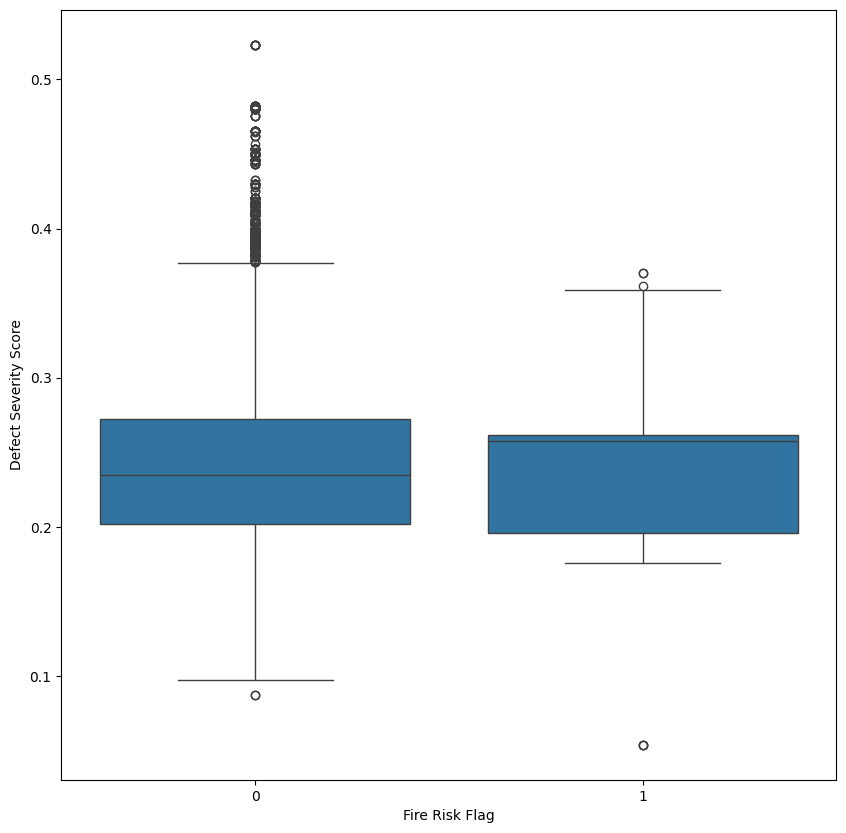

In [34]:
plt.figure(figsize=(10, 10))

sns.boxplot(
    data=df,
    x='fire_risk_flag',
    y='defect_severity_score'
)

plt.xlabel('Fire Risk Flag')
plt.ylabel('Defect Severity Score')
plt.show()

In [36]:
categorical = df.select_dtypes(include=['object']).columns
categorical

Index(['record_id', 'recall_campaign_id', 'manufacturer_campaign_id',
       'vehicle_make', 'vehicle_model', 'vehicle_era', 'manufacturer_name',
       'manufacturer_text', 'make_origin', 'recall_type_code',
       'recall_type_label', 'component_name', 'component_category',
       'recall_date_parsed', 'report_received_date',
       'notification_date_parsed', 'recall_scale', 'defect_summary',
       'consequence_summary', 'corrective_action', 'notes', 'defect_severity',
       'risk_tier', 'influenced_by', 'data_source', 'source_url',
       'scrape_date', 'dataset_version', 'RCL_CMPT_ID', 'MFR_COMP_NAME',
       'MFR_COMP_DESC', 'MFR_COMP_PTNO', 'creation_date_parsed'],
      dtype='object')

In [37]:
for col in categorical:
    print(col, ": ", df[col].nunique())

record_id :  47707
recall_campaign_id :  5511
manufacturer_campaign_id :  3791
vehicle_make :  789
vehicle_model :  5048
vehicle_era :  5
manufacturer_name :  808
manufacturer_text :  616
make_origin :  7
recall_type_code :  4
recall_type_label :  4
component_name :  461
component_category :  14
recall_date_parsed :  2683
report_received_date :  2
notification_date_parsed :  2733
recall_scale :  5
defect_summary :  5502
consequence_summary :  3544
corrective_action :  5478
notes :  426
defect_severity :  4
risk_tier :  3
influenced_by :  3
data_source :  1
source_url :  1
scrape_date :  1
dataset_version :  1
RCL_CMPT_ID :  47707
MFR_COMP_NAME :  1945
MFR_COMP_DESC :  2022
MFR_COMP_PTNO :  2080
creation_date_parsed :  2644


In [38]:
for col in categorical:
    if df[col].nunique() < 100:
        print(col, ": ", df[col].nunique())

vehicle_era :  5
make_origin :  7
recall_type_code :  4
recall_type_label :  4
component_category :  14
report_received_date :  2
recall_scale :  5
defect_severity :  4
risk_tier :  3
influenced_by :  3
data_source :  1
source_url :  1
scrape_date :  1
dataset_version :  1


In [39]:
selected_cats = [
    'vehicle_era',
    'make_origin',
    'component_category',
    'recall_scale',
    'risk_tier'
]

encoding = pd.get_dummies(df[selected_cats], drop_first=True)

encoding.head()

,vehicle_era_1990s,vehicle_era_2000s,vehicle_era_2010s,vehicle_era_2020s,make_origin_European,make_origin_German,make_origin_Japanese,make_origin_Korean,make_origin_Other,make_origin_US Domestic,...,component_category_Steering,component_category_Suspension,component_category_Tires / Wheels,component_category_Visibility,recall_scale_MASSIVE,recall_scale_MEDIUM,recall_scale_MEGA,recall_scale_SMALL,risk_tier_LOW,risk_tier_MODERATE
0,True,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,False,True,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,True
2,False,True,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,False,True,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
4,False,True,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True


In [40]:
encoding.columns

Index(['vehicle_era_1990s', 'vehicle_era_2000s', 'vehicle_era_2010s',
       'vehicle_era_2020s', 'make_origin_European', 'make_origin_German',
       'make_origin_Japanese', 'make_origin_Korean', 'make_origin_Other',
       'make_origin_US Domestic', 'component_category_Brakes',
       'component_category_Child Seat', 'component_category_Electrical',
       'component_category_Engine / Powertrain',
       'component_category_Fire Risk', 'component_category_Fuel System',
       'component_category_Other', 'component_category_Seat Belts',
       'component_category_Software / EV', 'component_category_Steering',
       'component_category_Suspension', 'component_category_Tires / Wheels',
       'component_category_Visibility', 'recall_scale_MASSIVE',
       'recall_scale_MEDIUM', 'recall_scale_MEGA', 'recall_scale_SMALL',
       'risk_tier_LOW', 'risk_tier_MODERATE'],
      dtype='object')

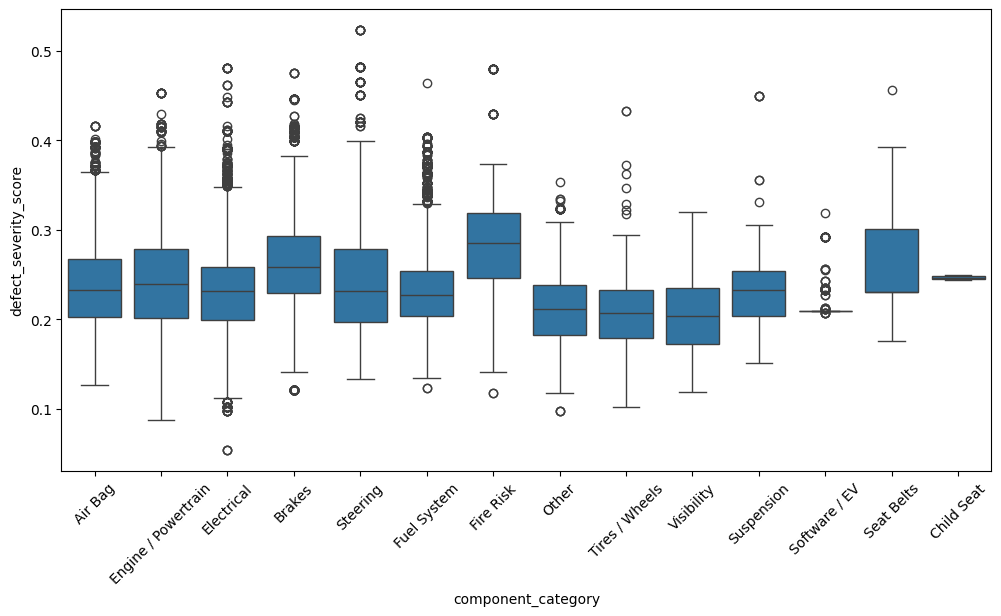

In [41]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='component_category',
    y='defect_severity_score'
)

plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='component_category'>

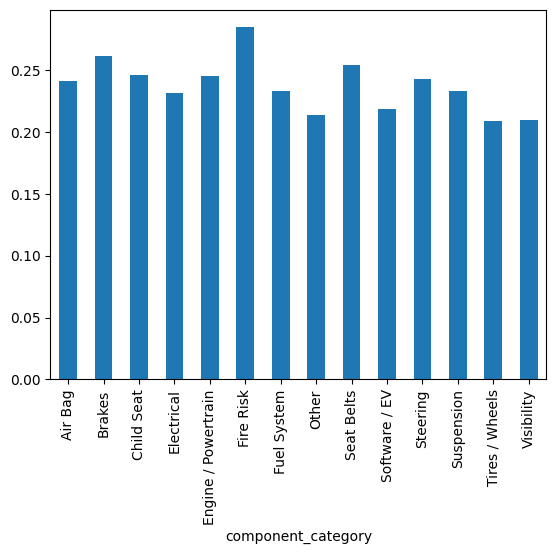

In [42]:
comp_group = df.groupby('component_category')['defect_severity_score'].mean()

comp_group.plot(kind='bar')

<Axes: xlabel='make_origin'>

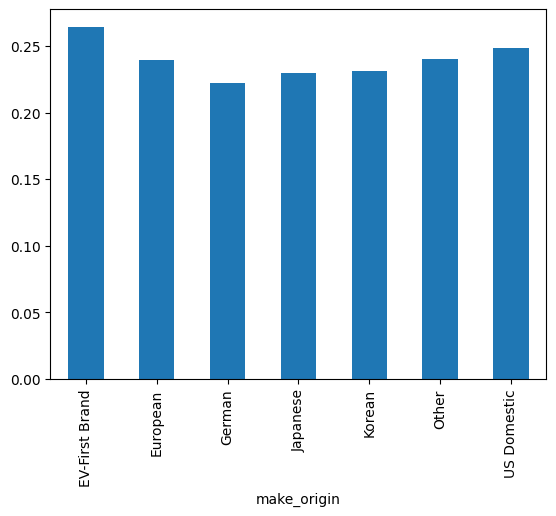

In [43]:
country_group = df.groupby('make_origin')['defect_severity_score'].mean()

country_group.plot(kind='bar')

<Axes: xlabel='vehicle_era,make_origin'>

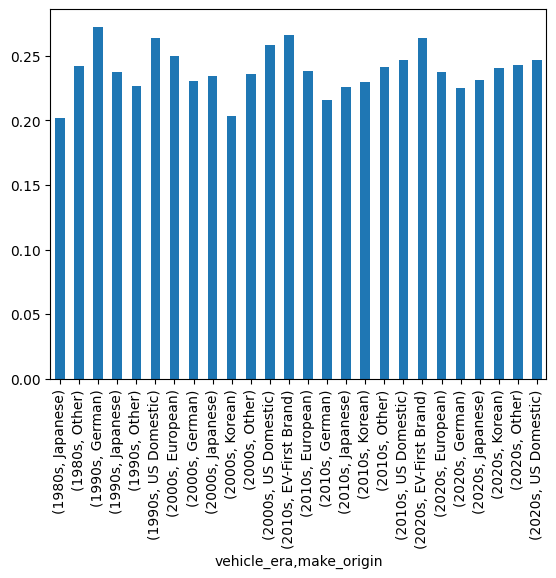

In [44]:
era_group = df.groupby(['vehicle_era', 'make_origin'])['defect_severity_score'].mean()

era_group.plot(kind='bar')

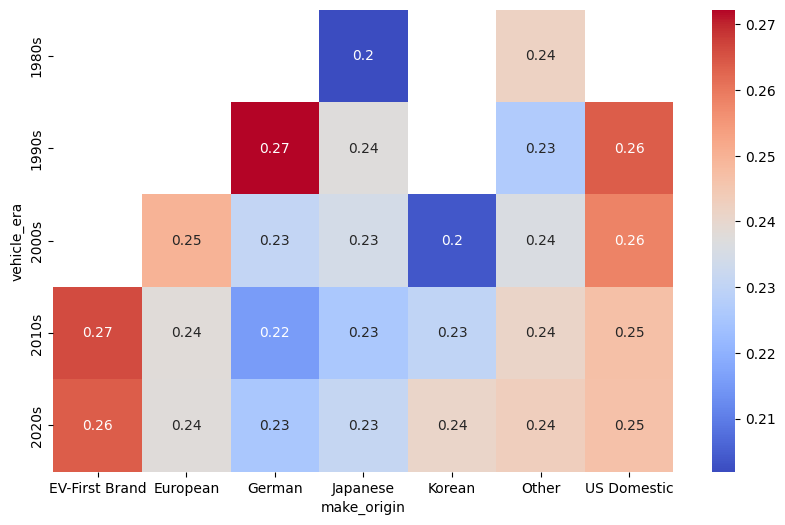

In [45]:
pivot = df.pivot_table(
    values='defect_severity_score',
    index='vehicle_era',
    columns='make_origin',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [46]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

,0
MFR_COMP_PTNO,30982
MFR_COMP_DESC,29537
MFR_COMP_NAME,28696
manufacture_date_end,24342
manufacture_date_begin,24234
manufacturer_campaign_id,14065
notes,3640
days_to_owner_notification,1224
notification_date_parsed,1224
owner_notification_date,1212


* Most columns have 1 or 0 missing values
* 6 columns have more than 10000 missing values -> but I think they are not that important columns -> just drop
* 7 columns have 1000-4000 missing values -> only three of them look important (vehicle_year, vehicle_era, and days_to_owner_notification) -> fillna

In [47]:
categorical = df.select_dtypes(
    include=['object']
).columns

for col in categorical:
  print(col, ": ", df[col].nunique())

record_id :  47707
recall_campaign_id :  5511
manufacturer_campaign_id :  3791
vehicle_make :  789
vehicle_model :  5048
vehicle_era :  5
manufacturer_name :  808
manufacturer_text :  616
make_origin :  7
recall_type_code :  4
recall_type_label :  4
component_name :  461
component_category :  14
recall_date_parsed :  2683
report_received_date :  2
notification_date_parsed :  2733
recall_scale :  5
defect_summary :  5502
consequence_summary :  3544
corrective_action :  5478
notes :  426
defect_severity :  4
risk_tier :  3
influenced_by :  3
data_source :  1
source_url :  1
scrape_date :  1
dataset_version :  1
RCL_CMPT_ID :  47707
MFR_COMP_NAME :  1945
MFR_COMP_DESC :  2022
MFR_COMP_PTNO :  2080
creation_date_parsed :  2644


In [48]:
categorical_features = [
    'vehicle_era',
    'make_origin',
    'component_category',
    'recall_scale',
    'risk_tier'
]

encoded = pd.get_dummies(df[categorical_features], drop_first=True)

encoded.head()

,vehicle_era_1990s,vehicle_era_2000s,vehicle_era_2010s,vehicle_era_2020s,make_origin_European,make_origin_German,make_origin_Japanese,make_origin_Korean,make_origin_Other,make_origin_US Domestic,...,component_category_Steering,component_category_Suspension,component_category_Tires / Wheels,component_category_Visibility,recall_scale_MASSIVE,recall_scale_MEDIUM,recall_scale_MEGA,recall_scale_SMALL,risk_tier_LOW,risk_tier_MODERATE
0,True,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,False,True,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,True
2,False,True,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,False,True,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
4,False,True,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True


In [49]:
numeric_features = [
    'recall_risk_score',
    'manufacturer_recall_count',
    'potential_units_affected',
    'days_to_owner_notification',
    'recall_age_days',
    'vehicle_year'
]

In [50]:
model_df = pd.concat(
    [df[numeric_features], encoded],
    axis=1
)

model_df['target'] = df['defect_severity_score']
model_df

,recall_risk_score,manufacturer_recall_count,potential_units_affected,days_to_owner_notification,recall_age_days,vehicle_year,vehicle_era_1990s,vehicle_era_2000s,vehicle_era_2010s,vehicle_era_2020s,...,component_category_Suspension,component_category_Tires / Wheels,component_category_Visibility,recall_scale_MASSIVE,recall_scale_MEDIUM,recall_scale_MEGA,recall_scale_SMALL,risk_tier_LOW,risk_tier_MODERATE,target
0,50,2407,5877718,67.0,4310,1998.0,True,False,False,False,...,False,False,False,False,False,True,False,False,True,0.3979
1,50,2407,5877718,67.0,4310,2005.0,False,True,False,False,...,False,False,False,False,False,True,False,False,True,0.3979
2,50,2407,5877718,67.0,4310,2001.0,False,True,False,False,...,False,False,False,False,False,True,False,False,True,0.3979
3,50,2407,5877718,67.0,4310,2000.0,False,True,False,False,...,False,False,False,False,False,True,False,False,True,0.3979
4,50,2407,5877718,67.0,4310,2002.0,False,True,False,False,...,False,False,False,False,False,True,False,False,True,0.3979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47702,24,384,2399,42.0,2209,2019.0,False,False,True,False,...,False,False,False,False,True,False,False,True,False,0.2884
47703,24,384,2399,42.0,2209,2018.0,False,False,True,False,...,False,False,False,False,True,False,False,True,False,0.2884
47704,24,384,2399,42.0,2209,2019.0,False,False,True,False,...,False,False,False,False,True,False,False,True,False,0.2884
47705,24,384,2399,42.0,2209,2018.0,False,False,True,False,...,False,False,False,False,True,False,False,True,False,0.2884


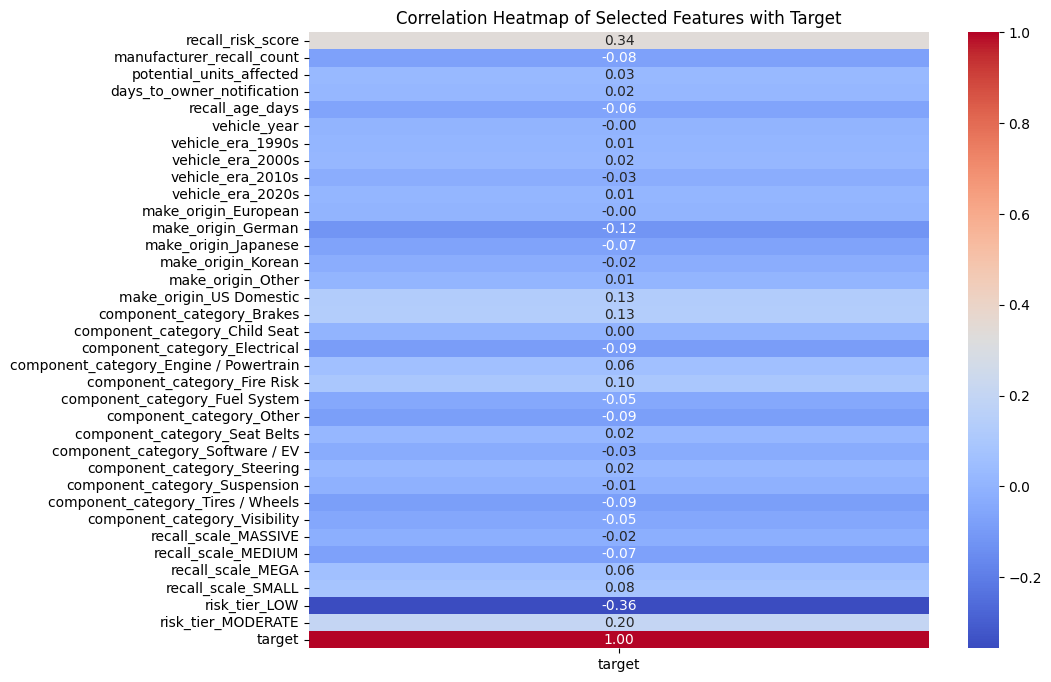

In [51]:
target_corr = model_df.corr()[['target']]

plt.figure(figsize=(10, 8))

sns.heatmap(
    target_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Selected Features with Target')
plt.show()

In [52]:
model_df.corr()['target'].sort_values(ascending=False)

,target
target,1.000000
recall_risk_score,0.339531
risk_tier_MODERATE,0.201209
component_category_Brakes,0.132775
make_origin_US Domestic,0.126456
component_category_Fire Risk,0.099342
recall_scale_SMALL,0.082439
component_category_Engine / Powertrain,0.058443
recall_scale_MEGA,0.058392
potential_units_affected,0.025742


In [53]:
# checking column types
for i in df.columns:
  print(f"\n{i}")
  types_in_col = df[i].apply(type).value_counts()
  for dtype, count in types_in_col.items():
    print(f"{dtype.__name__}: {count} values")
  if df[i].isna().sum() > 0:
    print(f"missing: {df[i].isna().sum()}")


record_id
str: 47707 values

nhtsa_record_id
int: 47707 values

recall_campaign_id
str: 47707 values

manufacturer_campaign_id
str: 33642 values
float: 14065 values
missing: 14065

vehicle_make
str: 47707 values

vehicle_model
str: 47707 values

vehicle_year
float: 47707 values
missing: 1002

vehicle_year_num
float: 47707 values
missing: 1002

vehicle_era
str: 46705 values
float: 1002 values
missing: 1002

manufacturer_name
str: 47707 values

manufacturer_text
str: 47707 values

make_origin
str: 47707 values

recall_type_code
str: 47707 values

recall_type_label
str: 47707 values

component_name
str: 47707 values

component_category
str: 47707 values

recall_initiation_date
int: 47707 values

recall_date_parsed
str: 47707 values

report_received_date
str: 47707 values

owner_notification_date
float: 47707 values
missing: 1212

notification_date_parsed
str: 46483 values
float: 1224 values
missing: 1224

manufacture_date_begin
float: 47707 values
missing: 24234

manufacture_date_end
flo

## Numerical Columns

In [54]:
numerical = df.select_dtypes(include='number').columns.tolist()
numerical

['nhtsa_record_id',
 'vehicle_year',
 'vehicle_year_num',
 'recall_initiation_date',
 'owner_notification_date',
 'manufacture_date_begin',
 'manufacture_date_end',
 'recall_year',
 'recall_month',
 'recall_quarter',
 'recall_age_days',
 'days_to_owner_notification',
 'potential_units_affected',
 'units_affected_num',
 'fire_risk_flag',
 'manufacturer_recall_count',
 'is_repeat_manufacturer',
 'recall_risk_score',
 'record_creation_date',
 'defect_severity_score']

In [55]:
# Numerical distributions:
  # nhtsa_record_id: unimodal, heavily right skewed
  # vehicle_year: unimodal, pretty normal, minimally left skewed
  # vehicle_year_num: same as ^?
  # recall_initiation_date: unimodal, centered, ROUGH normal shape but consistent distribution
  # owner_notification_date: unimodal, very similar to ^
  # manufacture_date_begin: unimodal, almost all on right end extreme, seemingly minimal difference between bins (0.02
  # manufacture_date_end: similar/same as ^
  # recall_year: unimodal, rough normal distribution, consistent on both sides
  # recall month: unimodal but not normal at all, mode at far right and pretty uniform elsewhere
  # recall_quarter: mostly 4 but each quarter has good count
  # recall_age_days: unimodal, roughly normal shape
  # days_to_owner: unimodal, not normal, mode far left, entirely skewed right, minimal far right outliers
  # potential_units_affected: ^ similar, same conclusions but different
  # units_affected_num: ^ similar, same conclusions but different
  # fire risk flag: from 0.0 to 1.0, two bins, one (0) overwhelming, other (1.0) minimal but there
  # manufacturer_recall_count: unimodal, high mode far left, skewed and outliers
  # is_repeat_manufacturer: seems to all be in 1.0 bin
  # recall_risk_score: unique shape, 3 L trend blocks, pretty uniform
  # record_creation_date: unimodal, roughly normal
  # defect_severity_score: roughly normal, but more data on right side than left

In [56]:
# to inspect more:
  # manufacture_date_begin and manufacture_date_end: check what kind of objects, convert to datetime
  # recall_month: categorical 1-12
  # recall_quarter: categorical 1.0-4.0

nhtsa_record_id


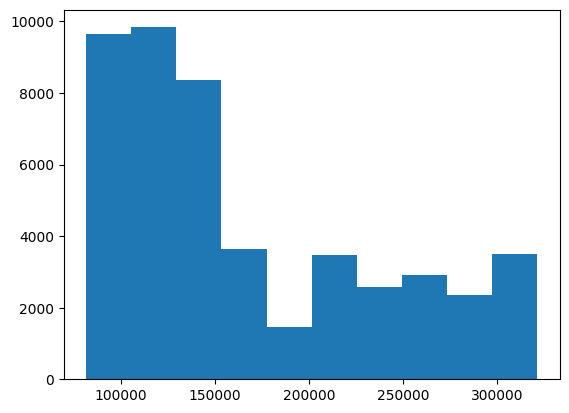

vehicle_year


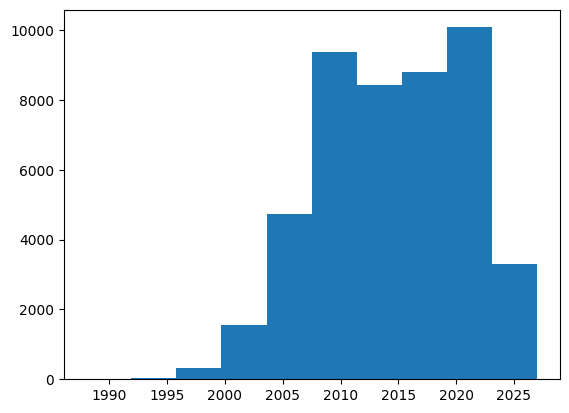

vehicle_year_num


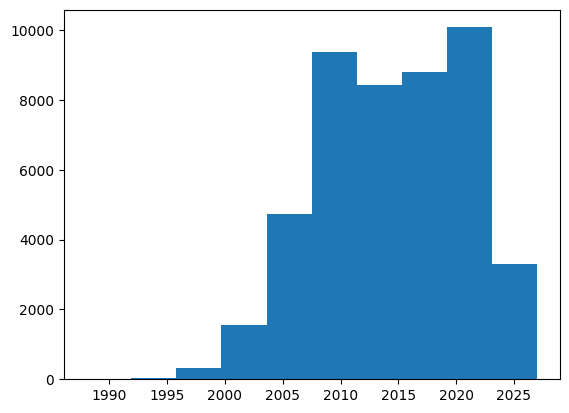

recall_initiation_date


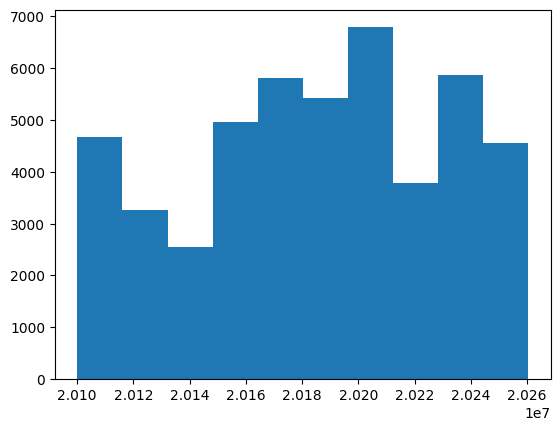

owner_notification_date


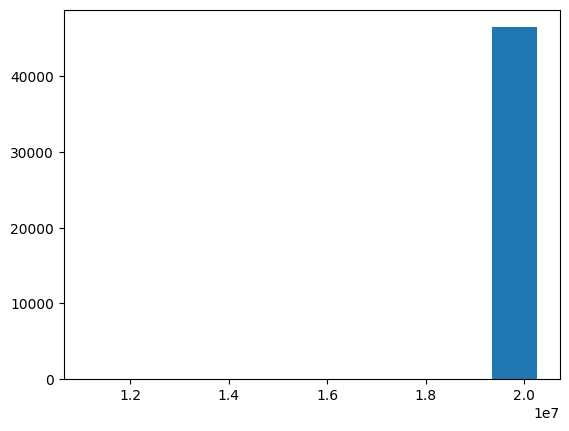

manufacture_date_begin


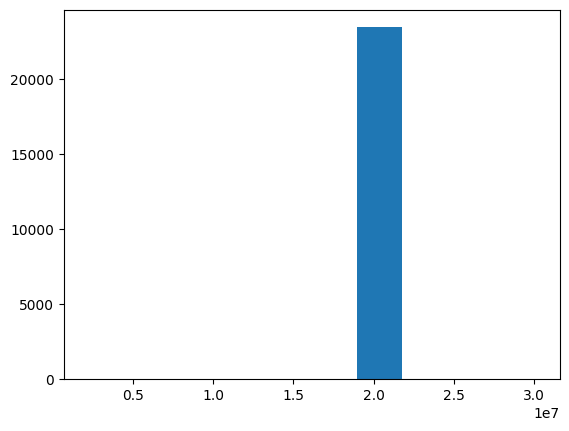

manufacture_date_end


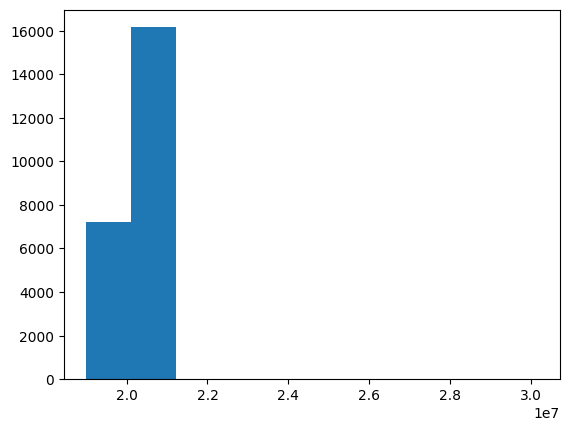

recall_year


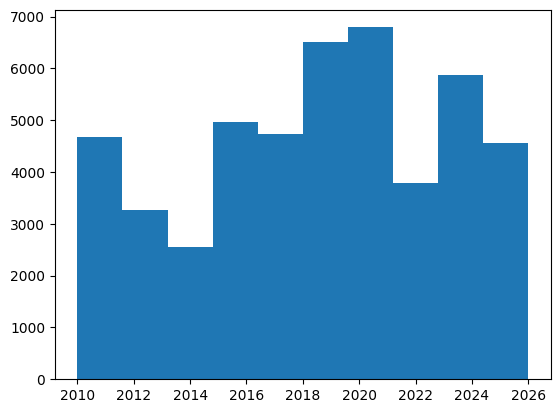

recall_month


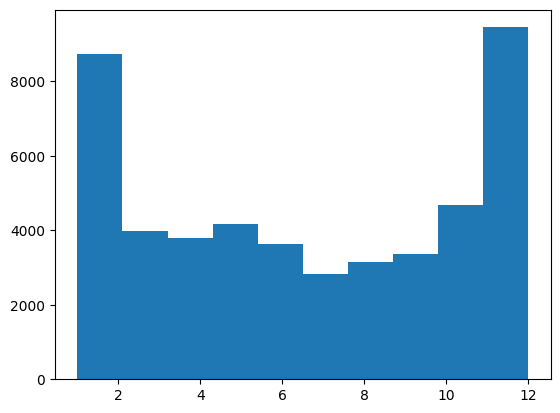

recall_quarter


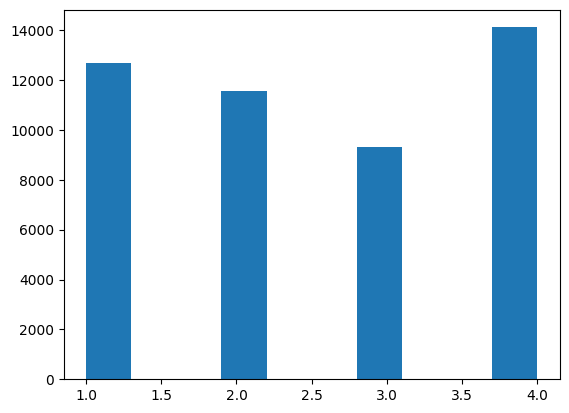

recall_age_days


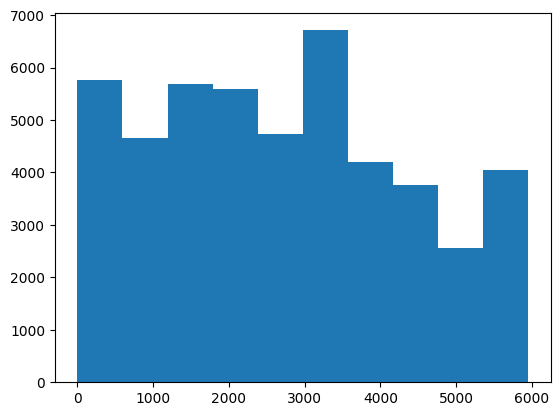

days_to_owner_notification


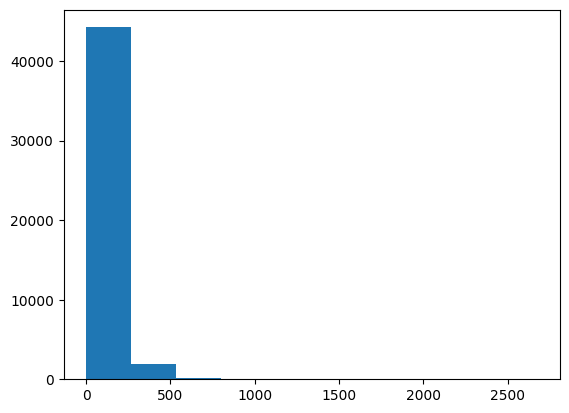

potential_units_affected


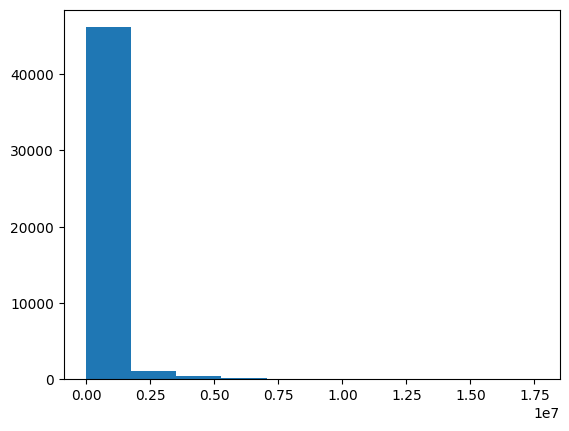

units_affected_num


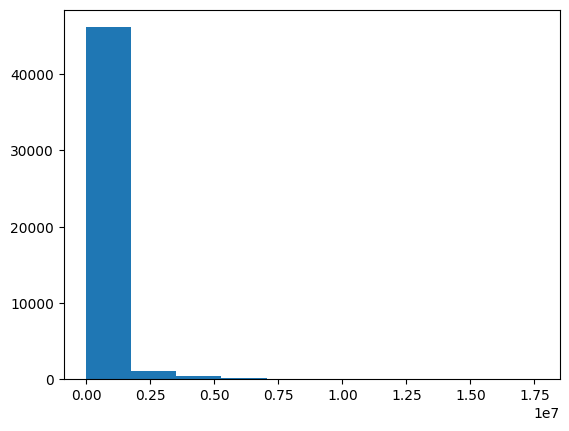

fire_risk_flag


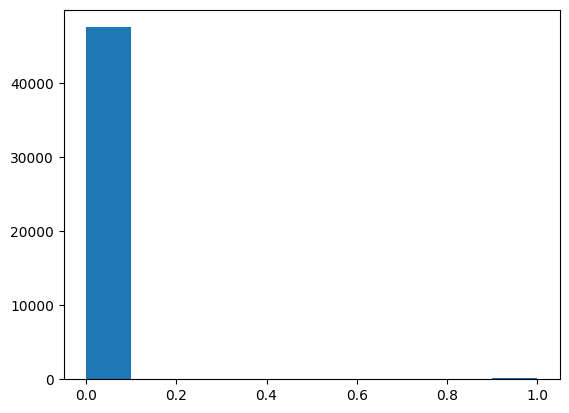

manufacturer_recall_count


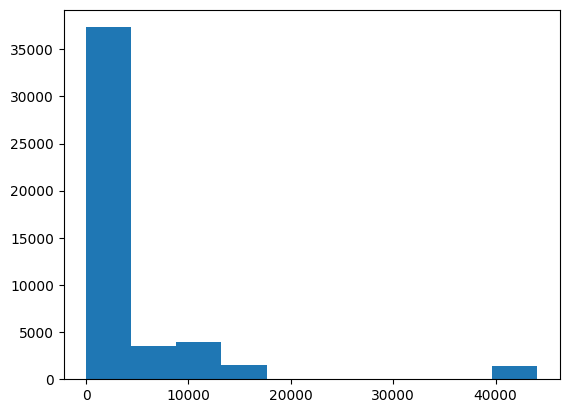

is_repeat_manufacturer


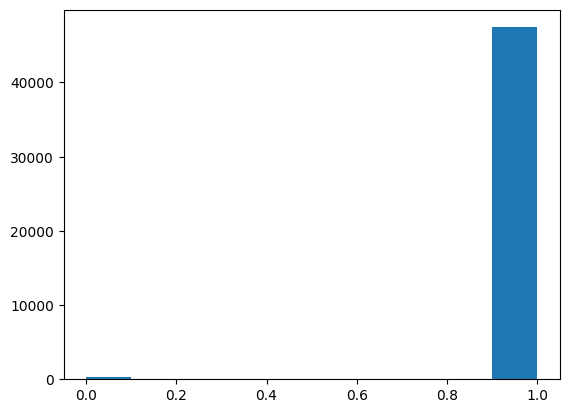

recall_risk_score


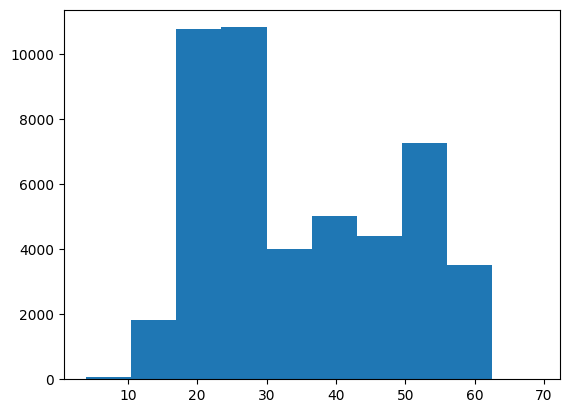

record_creation_date


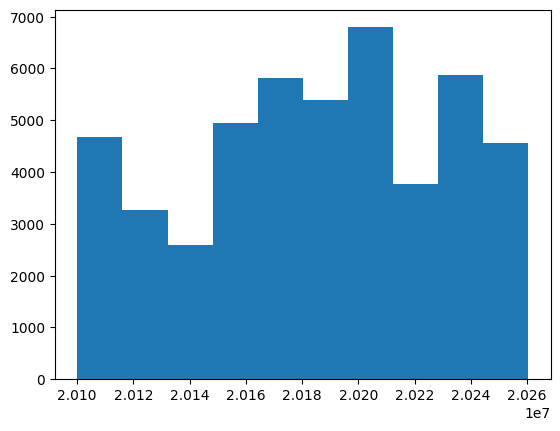

defect_severity_score


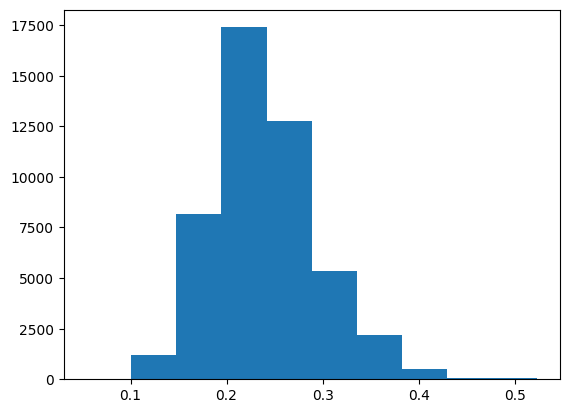

In [57]:
# inspecting col distributions
for col in numerical:
  print(f"{col}")
  plt.hist(df[col])
  plt.show()

# Missingness

In [58]:
# getting cols with missing vals

cols_with_nan = []

for i in df.columns:
  if df[i].isna().sum() > 0:
    cols_with_nan.append(i)

for i in cols_with_nan:
  print(i)

manufacturer_campaign_id
vehicle_year
vehicle_year_num
vehicle_era
owner_notification_date
notification_date_parsed
manufacture_date_begin
manufacture_date_end
days_to_owner_notification
notes
MFR_COMP_NAME
MFR_COMP_DESC
MFR_COMP_PTNO


# Categorical Features

In [59]:
# looking for finite categorical cols
categorical = df.select_dtypes(include='object').columns.tolist()
for col in categorical:
  print(f"\nColumn: {col}")
  print(f"Unique values count: {df[col].nunique()}")
  # print("Top 5 unique values and their counts:")
  # print(df[col].value_counts().head())


Column: record_id
Unique values count: 47707

Column: recall_campaign_id
Unique values count: 5511

Column: manufacturer_campaign_id
Unique values count: 3791

Column: vehicle_make
Unique values count: 789

Column: vehicle_model
Unique values count: 5048

Column: vehicle_era
Unique values count: 5

Column: manufacturer_name
Unique values count: 808

Column: manufacturer_text
Unique values count: 616

Column: make_origin
Unique values count: 7

Column: recall_type_code
Unique values count: 4

Column: recall_type_label
Unique values count: 4

Column: component_name
Unique values count: 461

Column: component_category
Unique values count: 14

Column: recall_date_parsed
Unique values count: 2683

Column: report_received_date
Unique values count: 2

Column: notification_date_parsed
Unique values count: 2733

Column: recall_scale
Unique values count: 5

Column: defect_summary
Unique values count: 5502

Column: consequence_summary
Unique values count: 3544

Column: corrective_action
Unique v

In [60]:
# cols where I can exploit categories

finite_categorical = []

for col in categorical:
  if df[col].nunique() < 50:
    print(f"\n{col}")
    print(f"Unique values count: {df[col].nunique()}")
    finite_categorical.append(col)


vehicle_era
Unique values count: 5

make_origin
Unique values count: 7

recall_type_code
Unique values count: 4

recall_type_label
Unique values count: 4

component_category
Unique values count: 14

report_received_date
Unique values count: 2

recall_scale
Unique values count: 5

defect_severity
Unique values count: 4

risk_tier
Unique values count: 3

influenced_by
Unique values count: 3

data_source
Unique values count: 1

source_url
Unique values count: 1

scrape_date
Unique values count: 1

dataset_version
Unique values count: 1


In [61]:
finite_categorical

['vehicle_era',
 'make_origin',
 'recall_type_code',
 'recall_type_label',
 'component_category',
 'report_received_date',
 'recall_scale',
 'defect_severity',
 'risk_tier',
 'influenced_by',
 'data_source',
 'source_url',
 'scrape_date',
 'dataset_version']

In [62]:
# categorical distribution conclusions:
  # vehicle_era: mostly 2010s, less and less as more in the past
    # strategy: is_2010s col
  # make_origin: mostly US_domestic
    # make is_US_domestic col
    # make is_other col, other is next biggest
  # recall_type_code
    # overwhelmingly V
    # some E
    # minimal others (T or C)
  # recall_type_label
    # same as above but words instead
  # component category: good amount of categories
  # report_received_date: binary but all No, no Yes
  # recall_scale: 4 level ordinal
    # ordinal encode
    # Medium Large Massive Mega
  # defect_severity: 4 level ordinal
    # pretty uniform
    # ordinal encode
    # LOW MEDIUM HIGH CRITICAL
  # risk_tier
    # 3 level ordinal
    # ordinal encode
    # LOW MEDIUM HIGH
    # most lows then med then high
  # influenced_by
    # 3 level ordinal
    # ordinal encode
    # mostly MFR, some ODI, no OVSC
  # data_source
    # one value, NHTSA ODI Flat File
  # source_url
    # one value, url
  # scrape_date
    # all one day, 2026-04-21
  # dataset_version
    # all one version, v1.0


vehicle_era


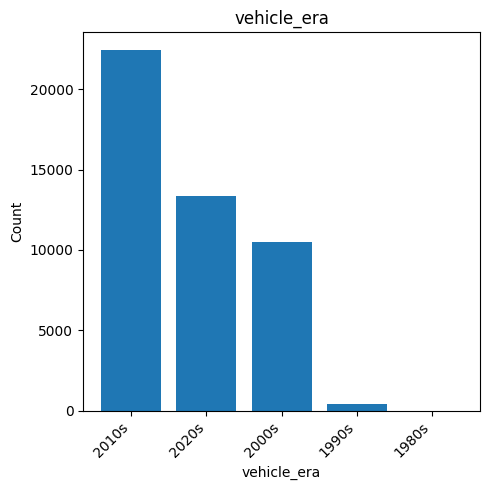


make_origin


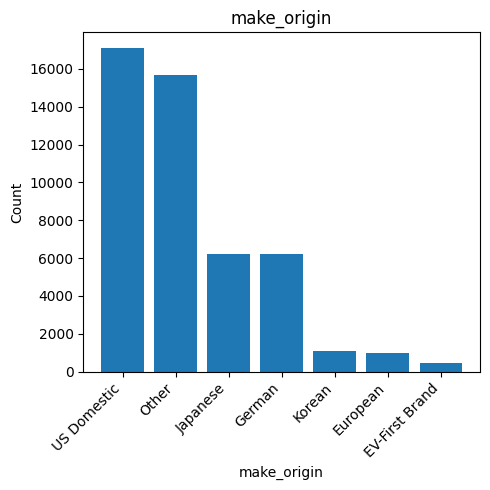


recall_type_code


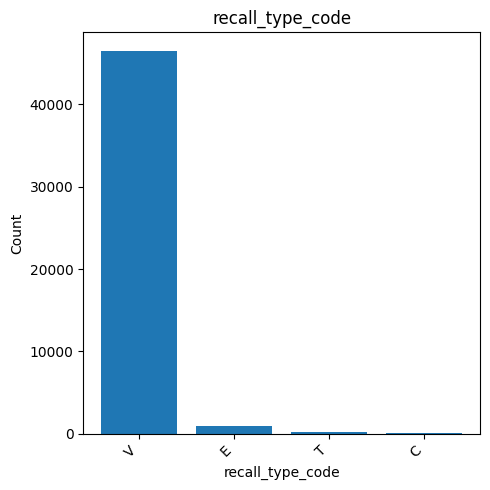


recall_type_label


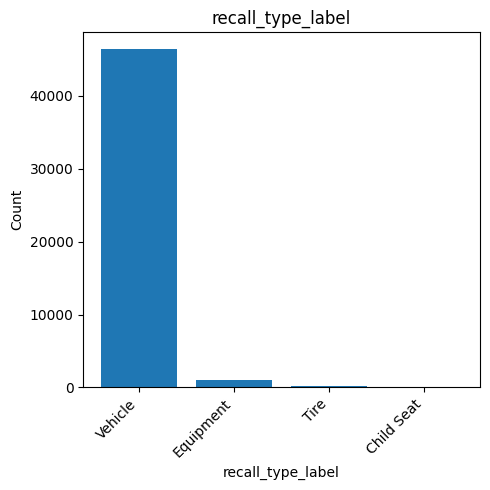


component_category


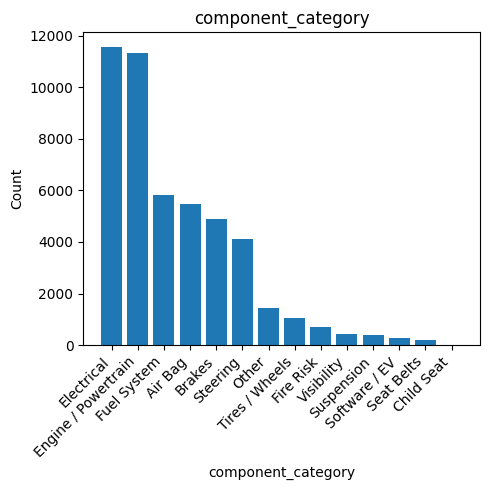


report_received_date


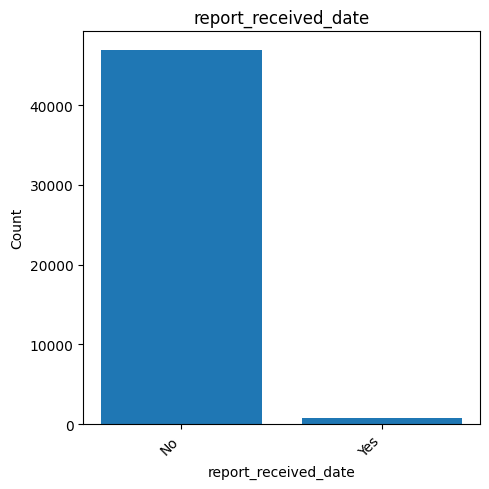


recall_scale


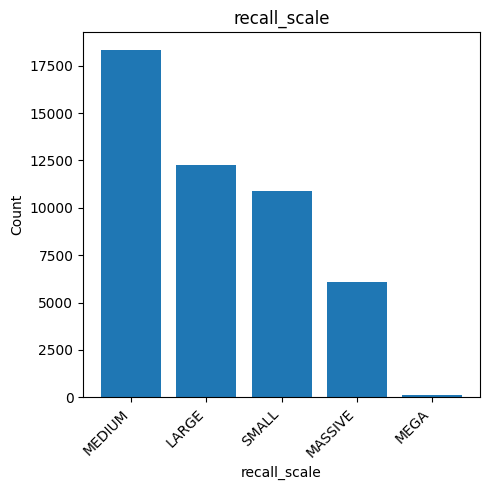


defect_severity


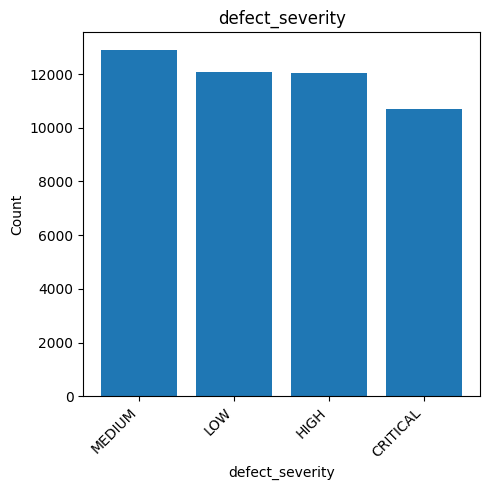


risk_tier


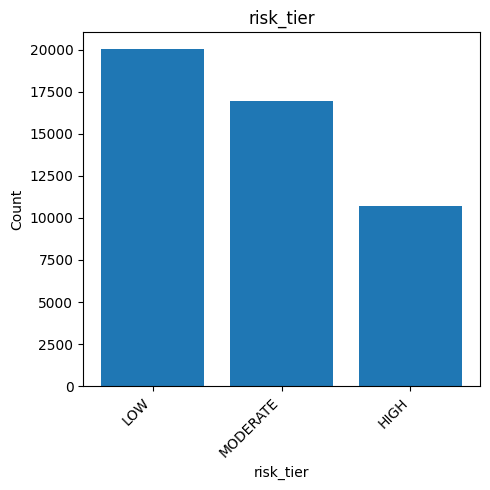


influenced_by


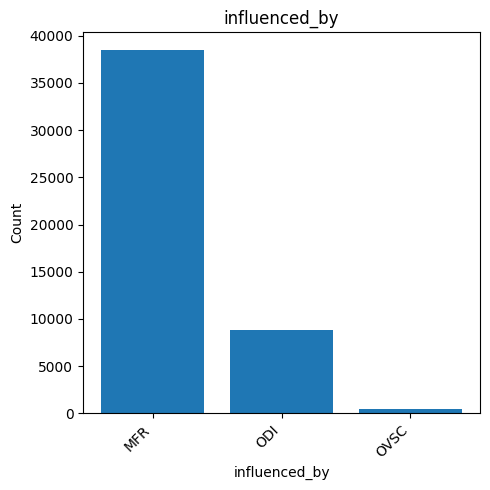


data_source


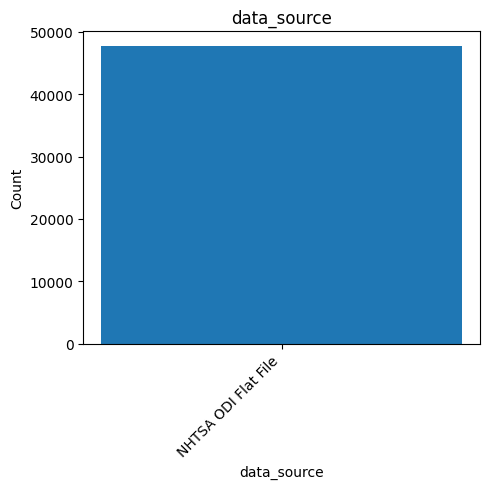


source_url


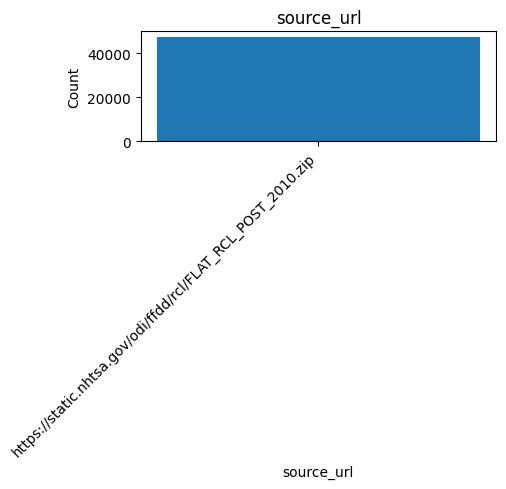


scrape_date


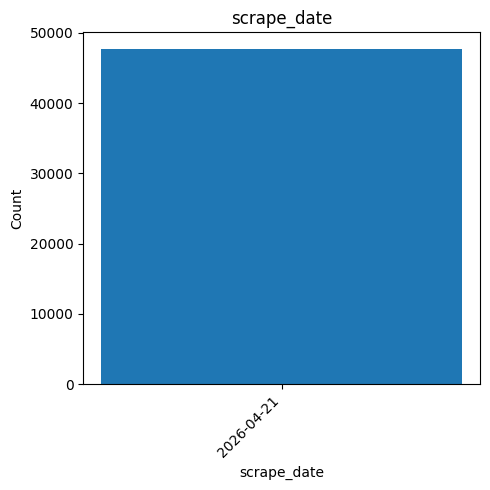


dataset_version


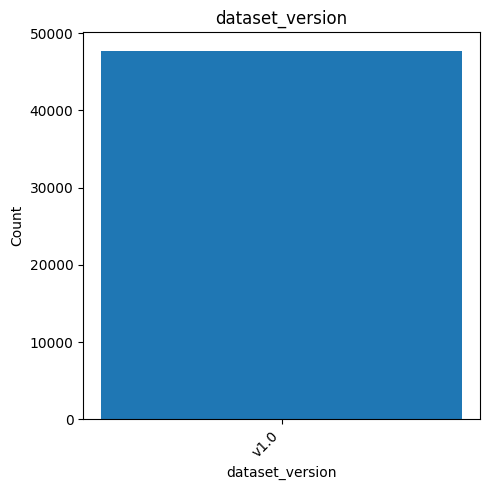

In [63]:
# plotting categorical
for col in finite_categorical:
  print(f"\n{col}")
  counts = df[col].value_counts()
  plt.figure(figsize=(5, 5))
  plt.bar(counts.index.astype(str), counts.values)
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.title(f"{col}")
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()

In [64]:
# columns to drop

to_drop = [
    'data_source',
    'source_url',
    'scrape_date',
    'dataset_version',
    'recall_type_label',
    'report_received_date'
]

df = df.drop(columns = to_drop)

In [65]:
# numerical columns to include (only ones with correlation)

numerical = [
    'recall_age_days',  # no missing
    'recall_year',  # no missing
    'vehicle_year' # mean impute
]

In [66]:
# mean impute

def mean_impute(x, mean):
  if pd.isna(x) or x in [None, 'None', 'none', 'NaN', np.nan, 'nan', '']:
    return mean
  return x

df['vehicle_year'] = df['vehicle_year'].apply(mean_impute, args = (df['vehicle_year'].mean(),))

In [67]:
# EDA component_category

df['component_category']

,component_category
0,Air Bag
1,Air Bag
2,Air Bag
3,Air Bag
4,Air Bag
...,...
47702,Steering
47703,Steering
47704,Steering
47705,Steering


In [68]:
df.groupby('component_category')['recall_age_days'].mean()

,recall_age_days
component_category,
Air Bag,2845.664108
Brakes,2394.719640
Child Seat,198.500000
Electrical,3122.008043
Engine / Powertrain,2420.687346
Fire Risk,3305.052478
Fuel System,2517.194540
Other,2268.378116
Seat Belts,2041.641148


In [69]:
# Missingness for categorical cols

to_ordinal = [
    'vehicle_era',
    'recall_scale',
    'defect_severity',
    'risk_tier'
]

to_ohe = [
    'make_origin',
    'recall_type_code',
    'component_category',
    'influenced_by'
]

to_mode_impute = to_ordinal + to_ohe

def mode_impute(x, mode):
  if pd.isna(x) or x in [None, 'None', 'none', 'NaN', np.nan, 'nan', '']:
    return mode
  return x


for col in to_mode_impute:
  df[col] = df[col].apply(mode_impute, args = (df[col].mode()[0],))

In [70]:
df['defect_severity'].unique()

array(['HIGH', 'CRITICAL', 'LOW', 'MEDIUM'], dtype=object)

In [71]:
# ordinal encoding

ordinal_categories = [
    ['1990s', '2000s', '2010s', '1980s', '2020s'],
    ['SMALL', 'MEDIUM', 'LARGE', 'MASSIVE', 'MEGA'],
    ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL'],
    ['LOW', 'MODERATE', 'HIGH']
]

ordinal_transformer = OrdinalEncoder(
    categories = ordinal_categories,
    handle_unknown = 'use_encoded_value',
    unknown_value = -1
)

In [72]:
# transforming columns

y = df['defect_severity_score']

ct = ColumnTransformer(transformers = [
    ('ohe', OneHotEncoder(handle_unknown = 'ignore', drop = 'first'), to_ohe),
    ('oe', ordinal_transformer, to_ordinal)
    ],
    remainder = 'passthrough')

df = ct.fit_transform(df)

feature_names = ct.get_feature_names_out()
df = pd.DataFrame(df, columns = feature_names)

df = df[[col for col in df.columns
         if col.startswith('ohe__')
         or col.startswith('oe__')
         or col.replace('remainder__', '') in numerical]]

df.columns = (df.columns
               .str.replace('ohe__', '')
               .str.replace('oe__', '')
               .str.replace('remainder__', ''))

In [73]:
df['defect_severity'].unique()

array([2.0, 3.0, 0.0, 1.0], dtype=object)

In [74]:
df['vehicle_year'] = df['vehicle_year'].astype(int)

In [75]:
# correcting column types
print(df.dtypes)
print('\n')
print(df.dtypes.value_counts())

make_origin_European                      object
make_origin_German                        object
make_origin_Japanese                      object
make_origin_Korean                        object
make_origin_Other                         object
make_origin_US Domestic                   object
recall_type_code_E                        object
recall_type_code_T                        object
recall_type_code_V                        object
component_category_Brakes                 object
component_category_Child Seat             object
component_category_Electrical             object
component_category_Engine / Powertrain    object
component_category_Fire Risk              object
component_category_Fuel System            object
component_category_Other                  object
component_category_Seat Belts             object
component_category_Software / EV          object
component_category_Steering               object
component_category_Suspension             object
component_category_T

In [76]:
df = df.astype(float)

In [77]:
df['defect_severity'] = df['defect_severity'].astype(int)

In [78]:
df['defect_severity'].unique()

array([2, 3, 0, 1])

# Modeling (Old regression)

In [79]:
df = pd.concat([df, y], axis = 1)

In [80]:
df.columns

Index(['make_origin_European', 'make_origin_German', 'make_origin_Japanese',
       'make_origin_Korean', 'make_origin_Other', 'make_origin_US Domestic',
       'recall_type_code_E', 'recall_type_code_T', 'recall_type_code_V',
       'component_category_Brakes', 'component_category_Child Seat',
       'component_category_Electrical',
       'component_category_Engine / Powertrain',
       'component_category_Fire Risk', 'component_category_Fuel System',
       'component_category_Other', 'component_category_Seat Belts',
       'component_category_Software / EV', 'component_category_Steering',
       'component_category_Suspension', 'component_category_Tires / Wheels',
       'component_category_Visibility', 'influenced_by_ODI',
       'influenced_by_OVSC', 'vehicle_era', 'recall_scale', 'defect_severity',
       'risk_tier', 'vehicle_year', 'recall_year', 'recall_age_days',
       'defect_severity_score'],
      dtype='object')

In [81]:
df['defect_severity']

,defect_severity
0,2
1,2
2,2
3,2
4,2
...,...
47702,1
47703,1
47704,1
47705,1


In [82]:
df['defect_severity_score']

,defect_severity_score
0,0.3979
1,0.3979
2,0.3979
3,0.3979
4,0.3979
...,...
47702,0.2884
47703,0.2884
47704,0.2884
47705,0.2884


In [83]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns = 'defect_severity_score'), y, test_size = 0.2)

In [84]:
# making val set

X_trtrain, X_val, y_trtrain, y_val = train_test_split(X_train, y_train, test_size = 0.2)

In [85]:
# predicting mean
y_mean = y_train.mean()
mean_predicts = np.full(len(y_train), y_mean)
print(f"Mean-predict RMSE: {np.sqrt(((mean_predicts - y_train) ** 2).mean())}")

Mean-predict RMSE: 0.05459705300209729


In [86]:
# normal linear model
linreg = LinearRegression().fit(X_train, y_train)
lin_predictions = linreg.predict(X_train)
print(f"SLR RMSE: {np.sqrt(((lin_predictions - y_train)**2).mean())}")

SLR RMSE: 0.04833642982850041


Optimal Ridge Alpha: 0.001
Min Validation Ridge RMSE: 0.04793302950614934


<Axes: >

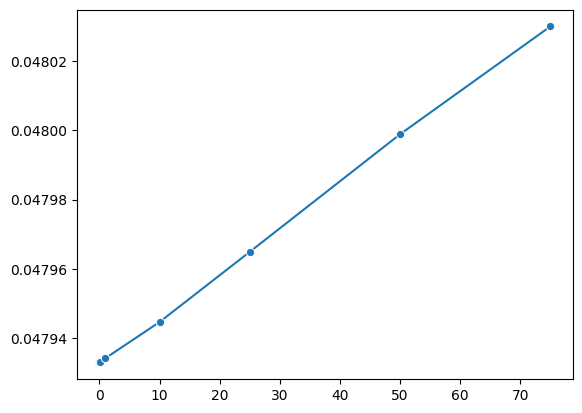

In [87]:
# ridge regression

alpha = [0.001, 0.01, 0.1, 1, 10, 25, 50, 75]
rmses = []

for a in alpha:
  ridge = Ridge(alpha = a).fit(X_trtrain, y_trtrain)
  ridge_predictions = ridge.predict(X_val)
  rmse = np.sqrt(((ridge_predictions - y_val)**2).mean())
  rmses.append(rmse)

alpha = np.array(alpha)
rmses = np.array(rmses)

best_idx = np.argmin(rmses)
print(f"Optimal Ridge Alpha: {alpha[best_idx]}")
print(f"Min Validation Ridge RMSE: {rmses[best_idx]}")

sns.lineplot(x = alpha, y = rmses, marker = 'o')

Optimal Lasso Alpha: 0.001
Min Validation Ridge RMSE: 0.04919764605741502


<Axes: >

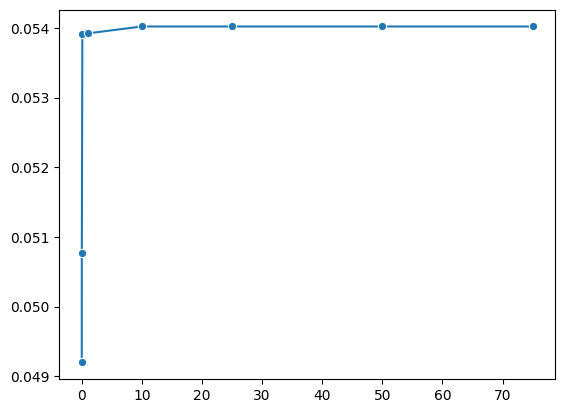

In [88]:
# Lasso

alpha = [0.001, 0.01, 0.1, 1, 10, 25, 50, 75]
rmses = []

for a in alpha:
  lasso = Lasso(alpha = a).fit(X_trtrain, y_trtrain)
  lasso_predictions = lasso.predict(X_val)
  rmse = np.sqrt(((lasso_predictions - y_val)**2).mean())
  rmses.append(rmse)


alpha = np.array(alpha)
rmses = np.array(rmses)

best_idx = np.argmin(rmses)
print(f"Optimal Lasso Alpha: {alpha[best_idx]}")
print(f"Min Validation Ridge RMSE: {rmses[best_idx]}")

sns.lineplot(x = alpha, y = rmses, marker = 'o')

In [89]:
# # Random forest regressor grid search

# param_grid = {
#     'n_estimators': [100, 200, 500],
#     'max_depth': [None, 5, 10, 20],
#     'max_features': ['sqrt', 'log2', 0.5],
#     'ccp_alpha': [0.0, 0.01, 0.1],
#     'min_samples_leaf': [1, 2, 5]
# }

# rf = RandomForestRegressor()

# gs = GridSearchCV(
#     rf,
#     param_grid,
#     cv = 5,
#     scoring = 'neg_root_mean_squared_error',
#     verbose = 2
# )

# gs.fit(X_trtrain, y_trtrain)
# print(gs.best_params_)
# print(f"Best CV RMSE: {-gs.best_score_:.4f}")

# best_rf = gs.best_estimator_
# preds = best_rf.predict(X_val)
# rmse = np.sqrt(((preds - y_val)**2).mean())
# print(f"Validation RMSE: {rmse:.4f}")

In [90]:
# # RF residuals

# y_pred = best_rf.predict(X_trtrain)  # or your val set
# residuals = y_trtrain - y_pred

# fig, axes = plt.subplots(1, 3, figsize=(15, 4))


# axes[0].scatter(y_pred, residuals, alpha=0.3)
# axes[0].axhline(0, color='red', linestyle='--')
# axes[0].set_xlabel('Predicted')
# axes[0].set_ylabel('Residuals')
# axes[0].set_title('Residuals vs Predicted')


# axes[2].hist(residuals, bins=50)
# axes[2].set_title('Residual Distribution')


# axes[1].scatter(y_trtrain, y_pred, alpha=0.3)
# axes[1].plot([y_trtrain.min(), y_trtrain.max()],
#              [y_trtrain.min(), y_trtrain.max()],
#              'r--')
# axes[1].set_xlabel('Actual')
# axes[1].set_ylabel('Predicted')
# axes[1].set_title('Actual vs Predicted')

# plt.tight_layout()
# plt.show()

In [91]:
# # rf_eval
# preds = best_rf.predict(X_val)

# rmse = np.sqrt(((preds - y_val)**2).mean())
# mae = np.abs(preds - y_val).mean()
# mean_actual = y_val.mean()
# std_actual = y_val.std()

# rmse_pct = (rmse / mean_actual) * 100

# print(f"RMSE:          {rmse:.4f}")
# print(f"MAE:           {mae:.4f}")
# print(f"Mean of target:{mean_actual:.4f}")
# print(f"Std of target: {std_actual:.4f}")
# print(f"RMSE % of mean:{rmse_pct:.2f}%")

In [92]:
# # r2 score
# r2 = r2_score(y_val, preds)
# print(f"R²: {r2:.4f}")

# Best Random Forest
* ccp_alpha: 0.0
* max_depth: None
* max_features: 0.5
* min_samples_leaf: 1
* n_estimators: 200

Best CV RMSE: 0.0172
Validation RMSE: 0.0154

In [93]:
# # Random forest regressor - depth 10

# rf10 = RandomForestRegressor(max_depth = 10).fit(X_train, y_train)
# rf10_predictions = rf10.predict(X_train)
# print(f"RF10 RMSE: {np.sqrt(((rf10_predictions - y_train)**2).mean())}")

In [94]:
# # Random forest regressor - depth 25

# rf25 = RandomForestRegressor(max_depth = 25).fit(X_train, y_train)
# rf25_predictions = rf25.predict(X_train)
# print(f"RF25 RMSE: {np.sqrt(((rf25_predictions - y_train)**2).mean())}")

In [95]:
# Boosting

# boost = GradientBoostingRegressor().fit(X_train, y_train)
# boost_predictions = boost.predict(X_train)
# print(f"Boosting RMSE: {np.sqrt(((boost_predictions - y_train)**2).mean())}")

In [96]:
# # XGBoosting grid search

# param_grid  = {
#     'n_estimators': [100, 300, 500], # number of trees
#     'learning_rate': [0.01, 0.05, 0.1, 0.2], # how much each tree correct previous error, low = robust but need more trees, high learn fast but can overfit
#     'max_depth': [3, 5, 7],
#     'reg_alpha': [0, 0.1, 1.0], # L1 regularization of leaf weights
#     'reg_lambda': [0.5, 1.0, 5.0], # L2 of leaf weights
# }

# xgb = XGBRegressor()

# gs = GridSearchCV(
#     xgb,
#     param_grid,
#     cv = 5,
#     scoring = 'neg_root_mean_squared_error',
#     verbose = 2
# )

# gs.fit(X_trtrain, y_trtrain)

# print(gs.best_params_)
# print(f"Best CV RMSE: {-gs.best_score_:.4f}")

In [97]:
# # boosting residuals

# y_pred = gs.best_estimator_.predict(X_trtrain)  # or your val set
# residuals = y_trtrain - y_pred

# fig, axes = plt.subplots(1, 3, figsize=(15, 4))


# axes[0].scatter(y_pred, residuals, alpha=0.3)
# axes[0].axhline(0, color='red', linestyle='--')
# axes[0].set_xlabel('Predicted')
# axes[0].set_ylabel('Residuals')
# axes[0].set_title('Residuals vs Predicted')


# axes[2].hist(residuals, bins=50)
# axes[2].set_title('Residual Distribution')


# axes[1].scatter(y_trtrain, y_pred, alpha=0.3)
# axes[1].plot([y_trtrain.min(), y_trtrain.max()],
#              [y_trtrain.min(), y_trtrain.max()],
#              'r--')
# axes[1].set_xlabel('Actual')
# axes[1].set_ylabel('Predicted')
# axes[1].set_title('Actual vs Predicted')

# plt.tight_layout()
# plt.show()

# Best Boosting Model

* learning_rate: 0.2
* max_depth: 7
* n_estimators: 500
* reg_alpha: 0
* reg_lambda: 0.5

In [98]:
# # best boosting
# best_boost = gs.best_estimator_
# preds = best_boost.predict(X_val)
# rmse = np.sqrt(((preds - y_val)**2).mean())
# print(f"Validation RMSE: {rmse:.4f}")

In [99]:
# # better boosting: more params
# param_grid_2 = {
#     'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],   # fraction of rows for tree
#     'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],  # fraction of features for tree
# }

# xgb2 = XGBRegressor(
#     n_estimators=gs.best_params_['n_estimators'],
#     learning_rate=gs.best_params_['learning_rate'],
#     max_depth=gs.best_params_['max_depth'],
#     reg_alpha=gs.best_params_['reg_alpha'],
#     reg_lambda=gs.best_params_['reg_lambda'],
# )

# gs2 = GridSearchCV(
#     xgb2,
#     param_grid_2,
#     cv = 5,
#     scoring = 'neg_root_mean_squared_error',
#     verbose = 2
# )

# gs2.fit(X_trtrain, y_trtrain)

# print(gs2.best_params_)
# print(f"Best CV RMSE: {-gs2.best_score_:.4f}")

# Classification of Defect Severity

# Final Model: Classification of defect_severity

In [100]:
df.columns

Index(['make_origin_European', 'make_origin_German', 'make_origin_Japanese',
       'make_origin_Korean', 'make_origin_Other', 'make_origin_US Domestic',
       'recall_type_code_E', 'recall_type_code_T', 'recall_type_code_V',
       'component_category_Brakes', 'component_category_Child Seat',
       'component_category_Electrical',
       'component_category_Engine / Powertrain',
       'component_category_Fire Risk', 'component_category_Fuel System',
       'component_category_Other', 'component_category_Seat Belts',
       'component_category_Software / EV', 'component_category_Steering',
       'component_category_Suspension', 'component_category_Tires / Wheels',
       'component_category_Visibility', 'influenced_by_ODI',
       'influenced_by_OVSC', 'vehicle_era', 'recall_scale', 'defect_severity',
       'risk_tier', 'vehicle_year', 'recall_year', 'recall_age_days',
       'defect_severity_score'],
      dtype='object')

In [101]:
# dropping columns we would not have at time of prediction
to_drop = [
    'defect_severity_score', # NN's confidence in defect_severity classification
    # 'recall_risk_score',  # pretty sure computed in part from defect_severity_score
    'risk_tier' # pretty sure from recall_risk_score
]

df = df.drop(columns = to_drop)

In [102]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns = 'defect_severity'), df['defect_severity'], test_size = 0.2, stratify = df['defect_severity'])

In [103]:
# making val set

X_trtrain, X_val, y_trtrain, y_val = train_test_split(X_train, y_train, test_size = 0.2, stratify = y_train)

In [104]:
y_trtrain.unique()

array([0, 1, 3, 2])

In [105]:
# baseline: logistic regression

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(solver='lbfgs', max_iter=1000))
]).fit(X_trtrain, y_trtrain)
preds = logreg.predict(X_val)
print("Accuracy:", accuracy_score(y_val, preds))

Accuracy: 0.47347045722520636


In [106]:
# Random forest classifier grid search

# param_grid = {
#     'n_estimators': [100, 200, 500],
#     'max_depth': [None, 5, 10, 20],
#     'max_features': ['sqrt', 'log2', 0.5],
#     'ccp_alpha': [0.0, 0.01, 0.1],
#     'min_samples_leaf': [1, 2, 5]
# }

# rf = RandomForestClassifier(class_weight='balanced', n_jobs = -1)

# gs_rf = GridSearchCV(
#     rf,
#     param_grid,
#     cv = 5,
#     scoring = 'f1_macro',
#     verbose = 2
# )

# gs_rf.fit(X_trtrain, y_trtrain)


# best_rf = gs_rf.best_estimator_
# preds = best_rf.predict(X_val)

# print("Accuracy:", accuracy_score(y_val, preds))
# print("\nClassification Report:\n", classification_report(y_val, preds))
# print(best_rf.get_params())

# ConfusionMatrixDisplay.from_predictions(y_val, preds)

Best Random Forest
* 92% validation accuracy
* booststrap: True
* ccp_alpha: 0.0
* class_weight: 'balanced'
* criterion: 'gini'
* max_depth: None
* max_features: 0.5
* max_leaf_nodes: None
* max_samples: None
* min_impurity_decrease: 0.0
* min_samples_leaf: 1
* min_samples_split: 2
* min_weight_fraction_leaf: 0.0
* monotonic_cst: None
* n_estimators: 200
* n_jobs: -1
* oob_score: False
* random_state: None
* verbose: 0
* warm_start: False

In [107]:
# best random forest

best_rf = RandomForestClassifier(
    ccp_alpha= 0.0,
    class_weight= 'balanced',
    criterion= 'gini',
    max_features= 0.5,
    min_impurity_decrease= 0.0,
    min_samples_leaf= 1,
    min_samples_split= 2,
    min_weight_fraction_leaf= 0.0,
    n_estimators= 200,
    n_jobs= -1,
    oob_score= False,
    verbose= 0,
).fit(X_trtrain, y_trtrain)

preds = best_rf.predict(X_val)


Accuracy: 0.9257172802305778

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.93      1932
           1       0.92      0.92      0.92      2065
           2       0.94      0.94      0.94      1925
           3       0.90      0.92      0.91      1711

    accuracy                           0.93      7633
   macro avg       0.93      0.93      0.93      7633
weighted avg       0.93      0.93      0.93      7633

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 0.5, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


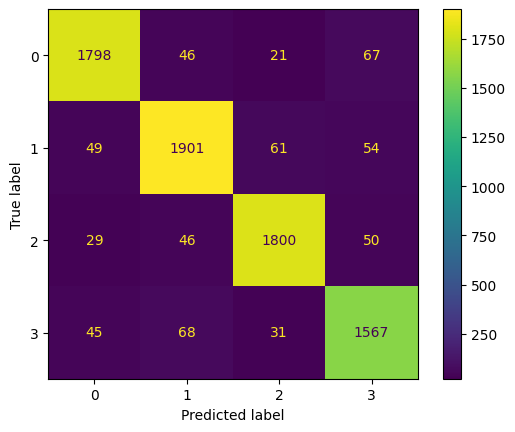

In [108]:
# Validation Performance
print("Accuracy:", accuracy_score(y_val, preds))
print("\nClassification Report:\n", classification_report(y_val, preds))
print(best_rf.get_params())

ConfusionMatrixDisplay.from_predictions(y_val, preds)

In [109]:
# Test Set Evaluation
test_preds_rf = best_rf.predict(X_test)
print("Accuracy:", accuracy_score(test_preds_rf, y_test))

Accuracy: 0.9305177111716622


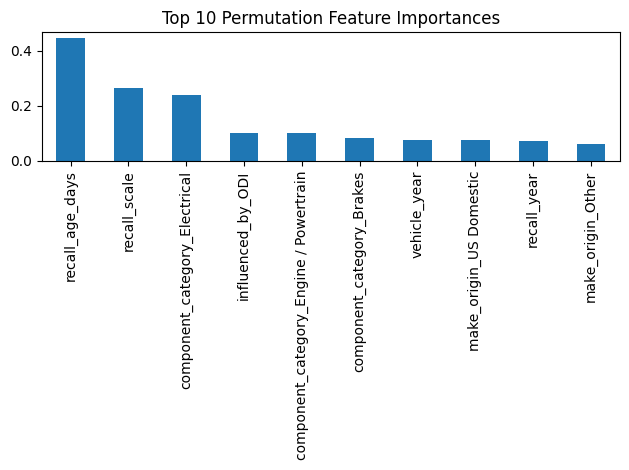

In [110]:
# feature importances for Random Forest: permutation importance

result = permutation_importance(best_rf, X_test, y_test, n_repeats=10)

importances_perm = pd.Series(result.importances_mean, index=X_test.columns)
top10_rf = importances_perm.sort_values(ascending=False).head(10)
top10_rf.plot(kind='bar', title='Top 10 Permutation Feature Importances')
plt.tight_layout()
plt.show()

In [111]:
# feature importance evaluation
X_trtrain['recall_age_days']

,recall_age_days
21172,1425.0
31787,2896.0
27813,3620.0
6387,2239.0
19020,2762.0
...,...
26376,4421.0
12302,3072.0
19124,1468.0
15254,214.0


In [112]:
df.groupby('defect_severity')['recall_age_days'].mean() #how long ago this particular recall was

,recall_age_days
defect_severity,
0,2807.875921
1,2723.562442
2,2512.453918
3,2685.915833


In [113]:
df['recall_scale'] # 4 level ordinal representing level of recall severity, as in how widespread/how many cars (categorical)

,recall_scale
0,4.0
1,4.0
2,4.0
3,4.0
4,4.0
...,...
47702,1.0
47703,1.0
47704,1.0
47705,1.0


In [114]:
# boosting grid search

# param_grid_xgb = {
#     'n_estimators': [100, 200, 500],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.1, 0.3],
#     'subsample': [0.7, 1.0],
#     'colsample_bytree': [0.7, 1.0]
# }

# xgb = XGBClassifier(
#     objective='multi:softmax',
#     num_class=4,
#     n_jobs=-1,
#     eval_metric='mlogloss'
# )

# gs_xgb = GridSearchCV(
#     xgb,
#     param_grid_xgb,
#     cv=5,
#     scoring='f1_macro',
#     verbose=2
# )

# gs_xgb.fit(X_trtrain, y_trtrain)

# best_xgb = gs_xgb.best_estimator_
# preds_xgb = best_xgb.predict(X_val)
# print(best_xgb.get_params())

# print("Accuracy:", accuracy_score(y_val, preds_xgb))
# print("\nClassification Report:\n", classification_report(y_val, preds_xgb))
# ConfusionMatrixDisplay.from_predictions(y_val, preds_xgb)

Best Boosting

* 90% validation accuracy
* 'objective': 'multi:softmax'
* 'base_score': None
* 'booster': None
* 'callbacks': None,
* 'colsample_bylevel': None
* 'colsample_bynode': None
* 'colsample_bytree': 1.0
* 'device': None
* 'early_stopping_rounds': None
* 'enable_categorical': False
* 'eval_metric': 'mlogloss'
* 'feature_types': None
* 'feature_weights': None
* 'gamma': None, 'grow_policy': None
* 'importance_type': None
* 'interaction_constraints': None
* 'learning_rate': 0.3
* 'max_bin': None
* 'max_cat_threshold': None
* 'max_cat_to_onehot': None
* 'max_delta_step': None
* 'max_depth': 7
* 'max_leaves': None
* 'min_child_weight': None
* 'missing': nan
* 'monotone_constraints': None
* 'multi_strategy': None
* 'n_estimators': 500
* 'n_jobs': -1
* 'num_parallel_tree': None
* 'random_state': None
* 'reg_alpha': None
* 'reg_lambda': None
* 'sampling_method': None
* 'scale_pos_weight': None
* 'subsample': 1.0, 'tree_method': None
* 'validate_parameters': None
* 'verbosity': None
* 'num_class': 4

{'objective': 'multi:softmax', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 1.0, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'mlogloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.3, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 7, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 500, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 1.0, 'tree_method': None, 'validate_parameters': None, 'verbosity': None, 'num_class': 4}
Accuracy: 0.8963710205685838

Classification Report:
           

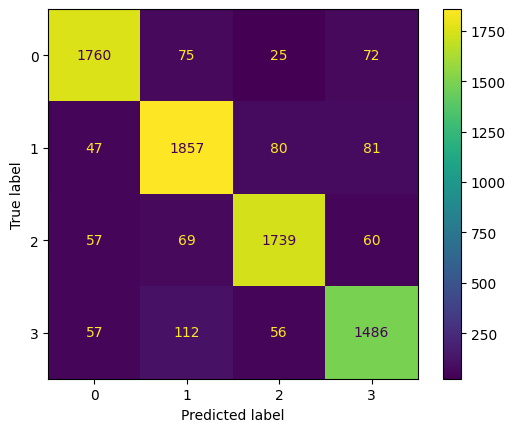

In [115]:
# best boosting

best_xgb = XGBClassifier(
    objective= 'multi:softmax',
    colsample_bytree= 1.0,
    enable_categorical= False,
    eval_metric= 'mlogloss',
    learning_rate= 0.3,
    max_depth= 7,
    missing= np.nan,
    n_estimators= 500,
    n_jobs= -1,
    subsample= 1.0,
    num_class= 4
).fit(X_trtrain, y_trtrain)
preds_xgb = best_xgb.predict(X_val)
print(best_xgb.get_params())

print("Accuracy:", accuracy_score(y_val, preds_xgb))
print("\nClassification Report:\n", classification_report(y_val, preds_xgb))
ConfusionMatrixDisplay.from_predictions(y_val, preds_xgb)

In [116]:
# Test Set Performance (boosting)

test_preds_xgb = best_xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, test_preds_xgb))

Accuracy: 0.9020121567805491


# Conclusion

* Best Model: Random Forest Classifier
  * Test Set Accuracy: 92%

In [117]:
# Classification Report:
#                precision    recall  f1-score   support

#            0       0.94      0.94      0.94      1932
#            1       0.93      0.91      0.92      2065
#            2       0.93      0.94      0.94      1925
#            3       0.90      0.91      0.91      1711

#     accuracy                           0.93      7633
#    macro avg       0.93      0.93      0.93      7633
# weighted avg       0.93      0.93      0.93      7633

In [118]:
test_preds_rf

array([1, 1, 0, ..., 3, 3, 1])

In [119]:
y_test_analysis = y_test.to_frame()

In [120]:
y_test_analysis['preds'] = test_preds_rf

In [121]:
y_test_analysis['correct'] = (y_test_analysis['defect_severity'] == y_test_analysis['preds'])

In [122]:
y_test

,defect_severity
37884,1
13721,1
45632,0
23373,1
32264,2
...,...
23012,3
45456,3
25057,0
5330,3


In [123]:
y_test_analysis.groupby('defect_severity').agg(
    correct=('correct', 'sum'),
    total = ('correct', 'size')).assign(
        accuracy = lambda x: x['correct']/x['total'])

,correct,total,accuracy
defect_severity,,,
0,2261,2415,0.936232
1,2383,2582,0.922928
2,2257,2407,0.937682
3,1978,2138,0.925164


In [124]:
# Good all around

In [125]:
# Next steps: model prioritizing high defect_severity